## Principal Portfolios with Dynamic Risk Overlays
**Saverio Lauriola — research notebook**

This notebook builds an **investable principal-portfolio baseline** on a US tech universe and studies **dynamic, implementation-aware risk overlays** on top of that baseline.

It contains four layers:

1. **Principal portfolios:** correlation-PCA factor-mimicking portfolios built from daily equity returns;
2. **Regime-aware diagnostics:** an implied-volatility state variable used to study conditional behaviour across risk regimes;
3. **Exploratory challengers:** short-horizon IV / downside-event overlay ideas, kept for research completeness but **not retained as the main overlay engine**;
4. **Current preferred path:** a **slow volatility-distribution overlay** built from HAR-RV plus residual bootstrap, evaluated **net of spread-based costs**.

**Main message.** In the current sample, **PC1 remains the most robust investable core exposure**. The strongest downstream extension is not a direct daily drawdown-event classifier, but a **slow, percentile-based volatility overlay** applied to the walk-forward PC1 strategy.

**How to use.** Run the notebook top-to-bottom. The core pipeline ends with the **net slow-overlay section**. The final appendix contains optional turnover, break-even, and cost diagnostics.


## Setup, parameters, and reusable helpers

In [1]:
# -------------------------
# PARAMETERS
# -------------------------
from yfinance import download
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


plt.rcParams["figure.figsize"] = (10, 4)
pd.options.display.float_format = "{:,.6f}".format

# Example single economy universe (US Tech)
TICKERS_US_TECH = ["AAPL","MSFT","GOOGL","AMZN","META","CSCO","NVDA","ORCL","NOW","ADBE","IBM","CRM","SHOP","INTU"]

# Global regime variable (use ONE series consistently across all economies)
IV_TICKER_PRIMARY = "^VXN"   # Nasdaq-100 implied vol
IV_TICKER_FALLBACK = "^VIX"  # fallback

# Historical risk-free proxy
RF_TICKER_PRIMARY = "^IRX"   # 13-week Treasury bill annualized yield proxy (Yahoo Finance)
RF_ANN = 252                 # trading-day annualization used for daily return conversion

START = "2015-01-01"
END   = "2026-01-31"

TRAIN_END_DEFAULT = "2022-12-31"
TEST_START_DEFAULT = "2023-01-01"

# Regime definition
REGIME_Q = (0.33, 0.66)     # low/mid/high cutoffs
REGIME_FREQ = "D"           # "D" or "W" (weekly)
SMOOTH_WINDOW = 5           # e.g. 5 trading days smoothing for log IV
EWMA_LAMBDA = 0.94          # for z-score of log IV (optional)

# PCA settings
K_BAR = 7                   # number of PCs to build portfolios for

# Portfolio normalisation
GROSS_NORM = 1.0            # enforce sum(abs(w)) = 1.0

# Walk-forward settings (optional)
WF_TRAIN_YEARS = 5          # rolling training window length
WF_STEP_MONTHS = 3          # rebalance / re-estimation frequency
WF_K_CHOICE = 7             # PCs in walk-forward (keep fixed for simplicity)

# Transaction cost model (used only in "tradable strategy" overlays)
TC_BPS = 10                 # bps per 1.0 turnover (gross)


In [2]:
# ============================================================
# HELPERS (keep everything reusable here)
# ============================================================

def linear_returns_from_prices(adj_close: pd.DataFrame) -> pd.DataFrame:
    return adj_close.pct_change().dropna(how="all")

def ewma_mean_std(x: pd.Series, lam: float = 0.94) -> pd.DataFrame:
    x = x.dropna().astype(float)
    m = np.zeros(len(x))
    v = np.zeros(len(x))
    m[0] = x.iloc[0]
    v[0] = 0.0
    for t in range(1, len(x)):
        m[t] = lam * m[t-1] + (1 - lam) * x.iloc[t]
        innov = x.iloc[t] - m[t-1]
        v[t] = lam * v[t-1] + (1 - lam) * innov**2
    s = np.sqrt(np.maximum(v, 1e-12))
    return pd.DataFrame({"ewma_mean": m, "ewma_std": s}, index=x.index)

def build_state_z_from_iv(iv_level: pd.Series,
                          freq: str = "D",
                          smooth_window: int = 5,
                          lam: float = 0.94,
                          use_zscore: bool = True) -> pd.Series:
    # Build z_t from implied vol level:
    #   x_t = log(IV_t)
    #   smooth(x_t) = rolling mean over past 'smooth_window' periods (incl. today)
    #   z_t = (smooth - ewma_mean) / ewma_std   (optional)
    iv = iv_level.dropna().astype(float)
    if freq.upper().startswith("W"):
        iv = iv.resample("W-FRI").last()  # align to week close
    x = np.log(iv)
    x_smooth = x.rolling(window=smooth_window, min_periods=smooth_window).mean().dropna()

    if not use_zscore:
        z = x_smooth.copy()
        z.name = "state_z"
        return z

    stats = ewma_mean_std(x_smooth, lam=lam)
    z = (x_smooth.loc[stats.index] - stats["ewma_mean"]) / stats["ewma_std"]
    z.name = "state_z"
    return z

def regime_labels_from_state(z: pd.Series,
                             q=(0.33, 0.66),
                             expanding: bool = True,
                             min_obs: int = 252) -> pd.Series:
    # Non-leaky LOW/MID/HIGH labels from z_t via expanding quantiles.
    z = z.dropna().astype(float)
    labels = pd.Series(index=z.index, dtype="object")

    q1, q2 = q
    if not expanding:
        a, b = z.quantile(q1), z.quantile(q2)  # leaky benchmark
        labels[z <= a] = "LOW"
        labels[(z > a) & (z <= b)] = "MID"
        labels[z > b] = "HIGH"
        return labels

    for i in range(len(z)):
        if i + 1 < min_obs:
            continue
        hist = z.iloc[: i + 1]
        a, b = hist.quantile(q1), hist.quantile(q2)
        zi = z.iloc[i]
        if zi <= a:
            labels.iloc[i] = "LOW"
        elif zi <= b:
            labels.iloc[i] = "MID"
        else:
            labels.iloc[i] = "HIGH"
    return labels.dropna()

def weighted_mean_cov(X: pd.DataFrame, p: pd.Series | None = None):
    # Mean/cov with optional probabilities p (must sum to 1 on index).
    if p is None:
        mu = X.mean(axis=0).values
        Xc = X.values - mu.reshape(1, -1)
        Sigma = (Xc.T @ Xc) / X.shape[0]
        return pd.Series(mu, index=X.columns, name="mu"), pd.DataFrame(Sigma, index=X.columns, columns=X.columns)

    X = X.loc[p.index].copy()
    w = p.values.reshape(-1, 1)
    mu = (w * X.values).sum(axis=0)
    Xc = X.values - mu.reshape(1, -1)
    Sigma = (w * Xc).T @ Xc
    return pd.Series(mu, index=X.columns, name="mu"), pd.DataFrame(Sigma, index=X.columns, columns=X.columns)

def correlation_pca(Sigma: np.ndarray):
    # Correlation PCA: rho = D^{-1} Sigma D^{-1}.
    Sigma = np.asarray(Sigma, dtype=float)
    vol = np.sqrt(np.clip(np.diag(Sigma), 1e-18, None))
    Dinv = np.diag(1.0 / vol)
    rho = Dinv @ Sigma @ Dinv
    lam, V = np.linalg.eigh(rho)   # ascending
    lam = lam[::-1]
    V = V[:, ::-1]

    # Sign convention: largest abs element in each eigenvector positive
    max_abs_row = np.argmax(np.abs(V), axis=0)
    s = np.sign(V[max_abs_row, np.arange(V.shape[0])])
    s[s == 0] = 1.0
    V = V * s.reshape(1, -1)
    return lam, V, vol, rho

def pc_portfolio_weights_from_corr_pca(V: np.ndarray, vol: np.ndarray, gross_norm: float = 1.0) -> pd.DataFrame:
    # Investible PC portfolios: w_k ∝ D^{-1} v_k, then normalize to sum(abs(w))=gross_norm.
    V = np.asarray(V, dtype=float)
    vol = np.asarray(vol, dtype=float)
    Dinv = 1.0 / vol
    W = V * Dinv.reshape(-1, 1)
    gross = np.sum(np.abs(W), axis=0)
    gross[gross == 0] = 1.0
    W = W / gross.reshape(1, -1) * gross_norm
    return pd.DataFrame(W)

def factor_returns(R: pd.DataFrame, W: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(R.values @ W.values, index=R.index, columns=[f"PC{i+1}" for i in range(W.shape[1])])

# ---------- Basic utilities ----------
def max_drawdown_from_wealth(wealth: pd.Series) -> float:
    wealth = wealth.dropna().astype(float)
    peak = wealth.cummax()
    dd = wealth/peak - 1.0
    return float(dd.min()) if len(dd) else np.nan

def ulcer_index(r: pd.Series) -> float:
    r = r.dropna().astype(float)
    if len(r)==0:
        return np.nan
    wealth = (1.0 + r).cumprod()
    peak = wealth.cummax()
    dd = wealth/peak - 1.0
    return float(np.sqrt(np.mean(dd**2)))

def cagr(r: pd.Series, ann: int = 252) -> float:
    r = r.dropna().astype(float)
    if len(r)==0:
        return np.nan
    wealth = (1.0 + r).cumprod()
    years = len(r)/ann
    return float(wealth.iloc[-1]**(1/years)-1) if years>0 else np.nan

def annualized_yield_pct_to_daily_return(y_ann_pct: pd.Series, ann: int = 252) -> pd.Series:
    """
    Convert an annualized yield quoted in percent (e.g. Yahoo ^IRX) into
    an approximate daily simple return using trading-day compounding.
    """
    y = pd.Series(y_ann_pct).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    y = (y / 100.0).clip(lower=-0.999999)
    rf_daily = (1.0 + y) ** (1.0 / ann) - 1.0
    rf_daily.name = "rf_daily"
    return rf_daily

def _coerce_rf_daily(r: pd.Series, rf_daily: float | pd.Series | None = 0.0) -> pd.Series:
    if rf_daily is None:
        return pd.Series(0.0, index=r.index, dtype=float, name="rf_daily")
    if np.isscalar(rf_daily):
        return pd.Series(float(rf_daily), index=r.index, dtype=float, name="rf_daily")
    rf = pd.Series(rf_daily, dtype=float).reindex(r.index).ffill().fillna(0.0)
    rf.name = getattr(rf_daily, "name", "rf_daily")
    return rf

# ---------- Performance metrics (historical RF-aware for Sharpe / Sortino / Martin) ----------
def perf_metrics(r: pd.Series, rf_daily: float | pd.Series | None = 0.0, ann: int = 252) -> dict:
    r = r.dropna().astype(float)
    if len(r) < 5:
        return {"n": int(len(r))}

    rf_s = _coerce_rf_daily(r, rf_daily)
    ex = r - rf_s

    mu_d = ex.mean()
    vol_d = ex.std(ddof=1)
    shr = (mu_d/vol_d)*np.sqrt(ann) if vol_d>0 else np.nan

    downside = ex.copy()
    downside[downside > 0] = 0.0
    dvol = downside.std(ddof=1)
    sor = (mu_d/dvol)*np.sqrt(ann) if dvol>0 else np.nan

    cagr_ = cagr(r, ann=ann)
    cagr_excess = cagr(ex, ann=ann) if (1.0 + ex).min() > 0 else np.nan
    wealth = (1.0 + r).cumprod()
    mxdd = max_drawdown_from_wealth(wealth)
    calmar = (cagr_/abs(mxdd)) if (mxdd < 0 and np.isfinite(mxdd)) else np.nan

    ui = ulcer_index(r)
    rf_cagr = cagr(rf_s, ann=ann)
    martin = ((cagr_ - rf_cagr)/ui) if (ui>0 and np.isfinite(ui)) else np.nan

    return {
        "n": int(len(r)),
        "CAGR": float(cagr_),
        "CAGR_excess": float(cagr_excess) if np.isfinite(cagr_excess) else np.nan,
        "RF_CAGR": float(rf_cagr) if np.isfinite(rf_cagr) else np.nan,
        "MxDD": float(mxdd),
        "ShR": float(shr),
        "SoR": float(sor),
        "Calmar": float(calmar),
        "Ulcer": float(ui),
        "Martin": float(martin),
    }

# ---------- Regimes ----------
def regime_from_state(z: pd.Series, q_low: float = 0.33, q_high: float = 0.66) -> pd.Series:
    z = z.dropna().astype(float)
    lo = z.quantile(q_low)
    hi = z.quantile(q_high)
    reg = pd.Series(index=z.index, dtype="object")
    reg[z <= lo] = "LOW"
    reg[(z > lo) & (z < hi)] = "MID"
    reg[z >= hi] = "HIGH"
    return reg

# ---------- Metrics tables (overall + conditional) ----------
def compute_metrics_by_regime(F: pd.DataFrame, reg: pd.Series, rf_daily: float | pd.Series | None = 0.0, ann: int = 252) -> dict:
    reg = reg.reindex(F.index).dropna()
    F = F.loc[reg.index]
    out = {"overall": {c: perf_metrics(F[c], rf_daily=rf_daily, ann=ann) for c in F.columns}}
    for rn in ["LOW","MID","HIGH"]:
        idx = reg[reg==rn].index
        out[rn] = {c: perf_metrics(F.loc[idx, c], rf_daily=rf_daily, ann=ann) for c in F.columns}
    return out

def table_from_metrics(mdict: dict, key: str) -> pd.DataFrame:
    rows=[]
    for regime_name, d in mdict.items():
        for pc, mets in d.items():
            rows.append({"regime": regime_name, "PC": pc, key: mets.get(key, np.nan)})
    return pd.DataFrame(rows).pivot(index="PC", columns="regime", values=key)

# ---------- Turnover / similarity ----------
def turnover(w_prev: np.ndarray, w_now: np.ndarray) -> float:
    w_prev = np.asarray(w_prev, float).ravel()
    w_now  = np.asarray(w_now, float).ravel()
    return float(np.sum(np.abs(w_now - w_prev)))

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    if na==0 or nb==0:
        return np.nan
    return float(np.dot(a,b)/(na*nb))

def align_signs_to_previous(W_prev: np.ndarray, W_now: np.ndarray) -> np.ndarray:
    # column-wise sign alignment using cosine similarity
    W_now = W_now.copy()
    for j in range(W_now.shape[1]):
        if cosine_sim(W_prev[:,j], W_now[:,j]) < 0:
            W_now[:,j] *= -1
    return W_now

def stability_from_W_hist(W_hist: list, pcs: list) -> pd.DataFrame:
    if len(W_hist) < 2:
        return pd.DataFrame()
    rows=[]
    for i in range(1, len(W_hist)):
        W_prev = W_hist[i-1]["W"][pcs].values
        W_now  = W_hist[i]["W"][pcs].values
        W_now  = align_signs_to_previous(W_prev, W_now)
        row={"rebalance": W_hist[i]["rebalance"]}
        for j,pc in enumerate(pcs):
            row[f"cos_{pc}"] = cosine_sim(W_prev[:,j], W_now[:,j])
            row[f"to_{pc}"]  = turnover(W_prev[:,j], W_now[:,j])
        rows.append(row)
    return pd.DataFrame(rows).set_index("rebalance")

# ---------- Politis–Romano stationary bootstrap ----------
def stationary_bootstrap_indices(T: int, avg_block_len: float, rng: np.random.Generator) -> np.ndarray:
    # Politis & Romano: block length geometric with mean avg_block_len
    p = 1.0/avg_block_len
    idx = np.empty(T, dtype=int)
    idx[0] = rng.integers(0, T)
    for t in range(1, T):
        if rng.random() < p:
            idx[t] = rng.integers(0, T)
        else:
            idx[t] = (idx[t-1] + 1) % T
    return idx

def stationary_bootstrap_df(df: pd.DataFrame, n_boot: int = 1000, avg_block_len: float = 10.0, seed: int = 1):
    rng = np.random.default_rng(seed)
    T = len(df)
    for _ in range(n_boot):
        ii = stationary_bootstrap_indices(T, avg_block_len, rng)
        yield df.iloc[ii].reset_index(drop=True)

def summarize_vec(x: np.ndarray) -> pd.Series:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x)==0:
        return pd.Series({"mean": np.nan, "p05": np.nan, "p50": np.nan, "p95": np.nan, "n": 0})
    return pd.Series({
        "mean": float(np.mean(x)),
        "p05": float(np.quantile(x, 0.05)),
        "p50": float(np.quantile(x, 0.50)),
        "p95": float(np.quantile(x, 0.95)),
        "n": int(len(x))
    })

def bootstrap_metric_tables(df_joint: pd.DataFrame,
                           pc_cols: list,
                           z_col: str = "z",
                           regime_q=(0.33,0.66),
                           metrics=("CAGR","ShR","SoR","Calmar","Martin","MxDD"),
                           n_boot: int = 1000,
                           avg_block_len: float = 10.0,
                           seed: int = 1,
                           rf_daily: float | pd.Series | None = 0.0,
                           ann: int = 252) -> dict:
    # returns dict[(metric, regime)] -> table PCs x {mean,p05,p50,p95,n}
    out={}
    sims = stationary_bootstrap_df(df_joint, n_boot=n_boot, avg_block_len=avg_block_len, seed=seed)
    mats={(m,rn): np.full((n_boot, len(pc_cols)), np.nan) for m in metrics for rn in ["overall","LOW","MID","HIGH"]}
    for i, sim in enumerate(sims):
        z = sim[z_col]
        reg = regime_from_state(z, q_low=regime_q[0], q_high=regime_q[1])
        F = sim[pc_cols]
        md = compute_metrics_by_regime(F, reg, rf_daily=rf_daily, ann=ann)
        for rn in ["overall","LOW","MID","HIGH"]:
            for j,pc in enumerate(pc_cols):
                for m in metrics:
                    mats[(m,rn)][i,j] = md[rn][pc].get(m, np.nan)
    for m in metrics:
        for rn in ["overall","LOW","MID","HIGH"]:
            rows=[]
            for j,pc in enumerate(pc_cols):
                s = summarize_vec(mats[(m,rn)][:,j]); s["PC"]=pc
                rows.append(s)
            out[(m,rn)] = pd.DataFrame(rows).set_index("PC").sort_values("mean", ascending=False)
    return out


# -------------------------
# Stationary Bootstrap (Politis–Romano)
# -------------------------
def stationary_bootstrap_indices(T: int, avg_block_len: float, rng: np.random.Generator):
    p = 1.0 / avg_block_len
    idx = np.empty(T, dtype=int)
    idx[0] = rng.integers(0, T)
    for t in range(1, T):
        if rng.random() < p:
            idx[t] = rng.integers(0, T)
        else:
            idx[t] = (idx[t-1] + 1) % T
    return idx

def stationary_bootstrap_series(df: pd.DataFrame, n_boot: int = 2000, avg_block_len: float = 10.0, seed: int = 0):
    rng = np.random.default_rng(seed)
    T = len(df)
    out = []
    for _ in range(n_boot):
        idx = stationary_bootstrap_indices(T, avg_block_len, rng)
        out.append(df.iloc[idx].reset_index(drop=True))
    return out

# -------------------------
# Politis–White style automatic block length (data-driven)
# -------------------------

def _autocov(x: np.ndarray, lag: int) -> float:
    """Sample autocovariance at lag (unbiased-ish)."""
    x = np.asarray(x, float)
    n = len(x)
    if lag >= n:
        return np.nan
    x0 = x[: n - lag]
    x1 = x[lag:]
    return float(np.mean((x0 - x0.mean()) * (x1 - x1.mean())))

def _long_run_var_bartlett(x: np.ndarray, L: int) -> float:

    g0 = _autocov(x, 0)
    s = g0
    for k in range(1, L + 1):
        wk = 1.0 - k / (L + 1.0)
        gk = _autocov(x, k)
        s += 2.0 * wk * gk
    return float(max(s, 1e-18))

def politis_white_block_length(
    s: pd.Series,
    use_abs: bool = True,
    max_lag: int | None = None,
    clip: tuple[int, int] = (2, 252),
) -> int:

    x = s.dropna().astype(float).values
    if use_abs:
        x = np.abs(x)

    T = len(x)
    if T < 50:
        # Too short: return something conservative
        return int(np.clip(10, *clip))

    # Choose truncation lag for long-run variance estimation (rule of thumb)
    if max_lag is None:
        max_lag = int(np.floor(T ** (1 / 3)))
        max_lag = max(5, min(max_lag, 200))

    # Long-run variance (captures dependence)
    lrv = _long_run_var_bartlett(x, L=max_lag)
    var = float(np.var(x, ddof=1))
    var = max(var, 1e-18)

    # Heuristic Politis–White style scaling:
    # L* ∝ (lrv/var)^(2/3) * T^(1/3)
    # (constant absorbed; in practice we calibrate gently with c=1.0)
    ratio = max(lrv / var, 1e-6)
    L_star = int(np.round((ratio ** (2 / 3)) * (T ** (1 / 3))))

    return int(np.clip(L_star, *clip))

# -------------------------
# Choose block length by matching volatility clustering (ACF)
# -------------------------

def _acf(x: np.ndarray, nlags: int) -> np.ndarray:

    x = np.asarray(x, float)
    x = x - np.mean(x)
    n = len(x)
    denom = np.dot(x, x)
    if denom <= 0:
        return np.zeros(nlags + 1)
    acf = np.empty(nlags + 1, float)
    acf[0] = 1.0
    for k in range(1, nlags + 1):
        acf[k] = np.dot(x[:-k], x[k:]) / denom
    return acf

def choose_block_length_by_acf_matching(
    s: pd.Series,
    candidates: list[int] = [5, 10, 20],
    nlags: int = 20,
    n_boot: int = 300,
    use_abs: bool = True,
    seed: int = 1,
    stationary_bootstrap_indices_fn=None,
    distance: str = "l2",
) -> dict:

    if stationary_bootstrap_indices_fn is None:
        raise ValueError("Pass your helper stationary_bootstrap_indices_fn (Politis–Romano indices generator).")

    r = s.dropna().astype(float)
    x = np.abs(r.values) if use_abs else r.values
    T = len(x)
    if T < nlags + 10:
        raise ValueError("Series too short for requested nlags.")

    target = _acf(x, nlags=nlags)

    rng = np.random.default_rng(seed)
    scores = {}
    boot_means = {}

    for L in candidates:
        acfs = np.zeros((n_boot, nlags + 1))
        for b in range(n_boot):
            ii = stationary_bootstrap_indices_fn(T, float(L), rng)
            xb = x[ii]
            acfs[b, :] = _acf(xb, nlags=nlags)
        m = acfs.mean(axis=0)
        boot_means[L] = m

        diff = m[1:] - target[1:]  # ignore lag0
        if distance == "l1":
            score = float(np.mean(np.abs(diff)))
        elif distance == "l2":
            score = float(np.sqrt(np.mean(diff**2)))
        elif distance == "weighted":
            # weight shorter lags more (more relevant for clustering)
            w = 1.0 / np.arange(1, nlags + 1)
            score = float(np.sqrt(np.mean((diff**2) * w)))
        else:
            raise ValueError("distance must be 'l1', 'l2', or 'weighted'.")

        scores[L] = score

    scores_ser = pd.Series(scores).sort_index()
    best_L = int(scores_ser.idxmin())

    return {
        "best_L": best_L,
        "scores": scores_ser,
        "target_acf": target,
        "boot_acf_mean": boot_means,
        "use_abs": use_abs,
        "nlags": nlags,
        "n_boot": n_boot,
        "distance": distance
    }

# -------------------------
# Compute and table regime-based risk & performance metrics
# -------------------------

def compute_metrics_from_joint(df: pd.DataFrame, regime_q=REGIME_Q):
    z = df["z"]
    rf = df["rf"] if "rf" in df.columns else 0.0
    reg = regime_from_state(z, q_low=regime_q[0], q_high=regime_q[1])
    out = {"overall": {}, "LOW": {}, "MID": {}, "HIGH": {}}
    for pc in PCS:
        out["overall"][pc] = perf_metrics(df[pc], rf_daily=rf)
        for rn in ["LOW","MID","HIGH"]:
            idx = reg[reg == rn].index
            rf_sub = rf.loc[idx] if hasattr(rf, "loc") else rf
            out[rn][pc] = perf_metrics(df.loc[idx, pc], rf_daily=rf_sub)
    return out

def summarize_vec(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x)==0:
        return {"mean": np.nan, "p05": np.nan, "p50": np.nan, "p95": np.nan, "n": 0}
    return {"mean": float(np.mean(x)),
            "p05": float(np.quantile(x, 0.05)),
            "p50": float(np.quantile(x, 0.50)),
            "p95": float(np.quantile(x, 0.95)),
            "n": int(len(x))}

def bootstrap_ci_table(metric_key: str, regime_name: str):
    mat = np.full((N_BOOT, len(PCS)), np.nan)
    for i, sim in enumerate(sims):
        res = compute_metrics_from_joint(sim)
        for j, pc in enumerate(PCS):
            mat[i, j] = res[regime_name][pc].get(metric_key, np.nan)
    rows=[]
    for j, pc in enumerate(PCS):
        s = summarize_vec(mat[:,j]); s["PC"]=pc
        rows.append(s)
    return pd.DataFrame(rows).set_index("PC").sort_values("mean", ascending=False)

# -------------------------
# Walk-forward PCA
# -------------------------
def add_months(ts: pd.Timestamp, m: int) -> pd.Timestamp:
    return (ts + pd.offsets.DateOffset(months=m)).normalize()

def walk_forward_pca(R: pd.DataFrame,
                     start_test: str,
                     train_years: int = 5,
                     step_months: int = 3,
                     k: int = 7,
                     gross_norm: float = 1.0,
                     tc_bps: float = 0.0):
    R = R.dropna()
    t0 = pd.Timestamp(start_test)
    t_end = R.index.max()

    weights_hist = []
    f_all = []
    costs_all = []
    w_prev = None

    reb = t0
    while True:
        train_start = reb - pd.DateOffset(years=train_years)
        train_end = reb - pd.DateOffset(days=1)
        test_start = reb
        test_end = add_months(reb, step_months) - pd.DateOffset(days=1)

        if test_start > t_end:
            break

        R_train = R.loc[train_start:train_end]
        R_test = R.loc[test_start:test_end]

        if len(R_train) < 252 or len(R_test) < 5:
            reb = add_months(reb, step_months)
            continue

        mu, Sigma = weighted_mean_cov(R_train)
        lam, V, vol, rho = correlation_pca(Sigma.values)
        W = pc_portfolio_weights_from_corr_pca(V[:, :k], vol, gross_norm=gross_norm)
        W.index = R.columns
        W.columns = [f"PC{i+1}" for i in range(W.shape[1])]

        f = factor_returns(R_test, W)
        f_all.append(f)

        if tc_bps > 0.0:
            w_now = W.values
            if w_prev is None:
                c = np.zeros(W.shape[1])
            else:
                to = np.array([turnover(w_prev[:, j], w_now[:, j]) for j in range(w_now.shape[1])])
                c = (tc_bps / 1e4) * to
            seg_cost = pd.DataFrame(0.0, index=R_test.index, columns=f.columns)
            seg_cost.iloc[0, :] = c
            costs_all.append(seg_cost)
            w_prev = w_now
        else:
            w_prev = W.values

        weights_hist.append({"rebalance": reb, "train_start": train_start, "train_end": train_end, "W": W})
        reb = add_months(reb, step_months)

    F = pd.concat(f_all).sort_index() if f_all else pd.DataFrame()
    C = pd.concat(costs_all).sort_index() if costs_all else pd.DataFrame(0.0, index=F.index, columns=F.columns)
    F_net = F - C.reindex(F.index).fillna(0.0)

    return F, F_net, weights_hist


## 1) Data download & returns

In [3]:
all_tickers = TICKERS_US_TECH + [IV_TICKER_PRIMARY, IV_TICKER_FALLBACK]
px = download(all_tickers, start=START, end=END, auto_adjust=False, progress=False).dropna(how="all")

px_adj_close_all = px["Adj Close"][TICKERS_US_TECH].copy()
px_high = px["High"][TICKERS_US_TECH].copy()
px_low = px["Low"][TICKERS_US_TECH].copy()

# For PCA we still want a common-support panel.
px_stocks = px_adj_close_all.dropna(how="any")

px_adj = px["Adj Close"].copy()
iv = px_adj[IV_TICKER_PRIMARY] if IV_TICKER_PRIMARY in px_adj.columns else None
if iv is None or iv.dropna().empty:
    iv = px_adj[IV_TICKER_FALLBACK]
iv.name = "IV"

R = linear_returns_from_prices(px_stocks)

# -------------------------
# Historical risk-free proxy
# -------------------------
rf_raw = download(RF_TICKER_PRIMARY, start=START, end=END, auto_adjust=False, progress=False)

def _extract_single_close(x):
    if isinstance(x, pd.Series):
        return x.astype(float)
    if not isinstance(x, pd.DataFrame):
        return pd.Series(dtype=float)
    for field in ["Adj Close", "Close"]:
        if field in x.columns:
            s = x[field]
            if isinstance(s, pd.DataFrame):
                s = s.iloc[:, 0]
            return s.astype(float)
    if x.shape[1] == 1:
        return x.iloc[:, 0].astype(float)
    return pd.Series(dtype=float)

rf_ann_pct = _extract_single_close(rf_raw).dropna()
if rf_ann_pct.empty:
    print(f"WARNING: no historical risk-free proxy downloaded from {RF_TICKER_PRIMARY}; using zero daily RF.")
    rf_daily_hist = pd.Series(0.0, index=R.index, name="rf_daily")
    rf_source_used = "ZERO_FALLBACK"
else:
    rf_daily_hist = annualized_yield_pct_to_daily_return(rf_ann_pct, ann=RF_ANN)
    rf_daily_hist = rf_daily_hist.reindex(R.index).ffill().fillna(0.0)
    rf_source_used = RF_TICKER_PRIMARY

print("R shape:", R.shape)
print(
    f"RF source: {rf_source_used} | "
    f"non-null daily obs on R index: {int(rf_daily_hist.notna().sum())} | "
    f"sample mean daily RF (bps): {1e4 * rf_daily_hist.mean():.4f}"
)
R.head()


R shape: (2690, 14)
RF source: ^IRX | non-null daily obs on R index: 2690 | sample mean daily RF (bps): 0.7967


Ticker,AAPL,MSFT,GOOGL,AMZN,META,CSCO,NVDA,ORCL,NOW,ADBE,IBM,CRM,SHOP,INTU
Date,,,,,,,,,,,,,,
2015-05-21,0.010226,-0.003363,0.007783,0.018331,-0.000869,-0.006414,-0.007129,-0.000226,0.018334,0.011933,-0.002417,0.039196,0.510588,0.007545
2015-05-22,0.008752,-0.010965,-0.004113,-0.009267,0.000745,-0.005776,-0.001436,-0.007904,-0.001395,-0.006455,-0.006461,0.028803,0.102414,0.024962
2015-05-26,-0.022031,-0.006610,-0.013219,-0.005051,-0.015024,-0.010595,-0.006232,-0.013658,-0.013332,-0.008496,-0.012136,-0.019197,0.047333,-0.019577
2015-05-27,0.018670,0.021893,0.012902,0.013984,0.015379,0.012436,0.053546,0.018694,0.008751,0.010081,0.010992,0.005165,-0.072513,0.004968
2015-05-28,-0.001969,-0.003361,-0.000126,-0.011242,-0.004966,0.001365,0.013737,-0.006343,0.000128,-0.001747,-0.001686,-0.017174,-0.001818,-0.000950


## 2) Build global regime variable and non‑leaky regime labels

HIGH    838
LOW     815
MID     786
Name: count, dtype: int64


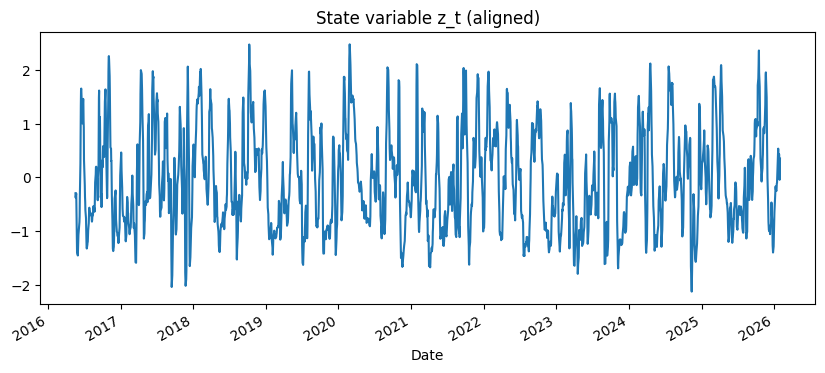

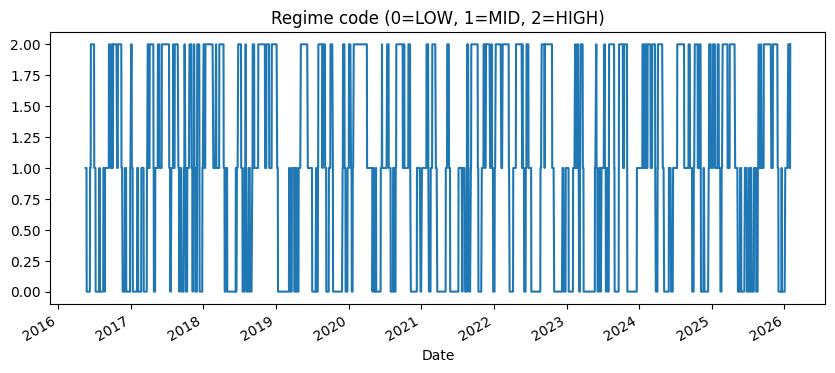

In [4]:
z = build_state_z_from_iv(iv, freq=REGIME_FREQ, smooth_window=SMOOTH_WINDOW, lam=EWMA_LAMBDA, use_zscore=True)
z_daily = z.reindex(R.index).ffill().dropna()

reg = regime_labels_from_state(z_daily, q=REGIME_Q, expanding=True, min_obs=252)

print(reg.value_counts())
z_daily.loc[reg.index].plot(title="State variable z_t (aligned)")
plt.show()

tmp = pd.DataFrame({"z": z_daily.loc[reg.index], "regime": reg})
tmp["regime_code"] = tmp["regime"].map({"LOW":0,"MID":1,"HIGH":2})
tmp["regime_code"].plot(title="Regime code (0=LOW, 1=MID, 2=HIGH)")
plt.show()


## 3) Static PCA (train) → factor portfolios → conditional performance (test)

In [5]:
train = R.loc[:TRAIN_END_DEFAULT].dropna()
test  = R.loc[TEST_START_DEFAULT:].dropna()

mu_hat, Sigma_hat = weighted_mean_cov(train)
lam, V, vol, rho = correlation_pca(Sigma_hat.values)

W = pc_portfolio_weights_from_corr_pca(V[:, :K_BAR], vol, gross_norm=GROSS_NORM)
W.index = R.columns
W.columns = [f"PC{i+1}" for i in range(W.shape[1])]

F_test = factor_returns(test, W)

reg_test = reg.reindex(F_test.index).dropna()
F_test = F_test.loc[reg_test.index]
rf_test = rf_daily_hist.reindex(F_test.index).ffill().fillna(0.0)

metrics_overall = {c: perf_metrics(F_test[c], rf_daily=rf_test) for c in F_test.columns}

def metrics_table(d: dict, key: str):
    return pd.Series({k: v.get(key, np.nan) for k,v in d.items()})

summary = pd.DataFrame({
    "CAGR": metrics_table(metrics_overall, "CAGR"),
    "CAGR_excess": metrics_table(metrics_overall, "CAGR_excess"),
    "RF_CAGR": metrics_table(metrics_overall, "RF_CAGR"),
    "ShR":  metrics_table(metrics_overall, "ShR"),
    "SoR":  metrics_table(metrics_overall, "SoR"),
    "Martin": metrics_table(metrics_overall, "Martin"),
    "MxDD": metrics_table(metrics_overall, "MxDD"),
    "Calmar": metrics_table(metrics_overall, "Calmar"),
})
print(f"Static test metrics: Sharpe / Sortino / Martin use historical RF proxy {rf_source_used}.")
summary


Static test metrics: Sharpe / Sortino / Martin use historical RF proxy ^IRX.


,CAGR,CAGR_excess,RF_CAGR,ShR,SoR,Martin,MxDD,Calmar
PC1,0.351555,0.291516,0.046534,1.325611,2.218360,6.006030,-0.241843,1.453651
PC2,0.038008,-0.008150,0.046534,-0.016642,-0.029067,-0.094035,-0.162138,0.234420
PC3,0.108572,0.059288,0.046534,0.607203,1.057447,1.007681,-0.148886,0.729230
PC4,0.130397,0.080146,0.046534,0.751983,1.302118,3.399106,-0.065132,2.002043
PC5,-0.018156,-0.061825,0.046534,-0.576034,-0.928931,-0.733706,-0.202945,-0.089461
PC6,0.072901,0.025198,0.046534,0.252926,0.441093,0.406983,-0.165965,0.439255
PC7,-0.086730,-0.127362,0.046534,-1.639133,-2.451327,-0.641431,-0.294495,-0.294503


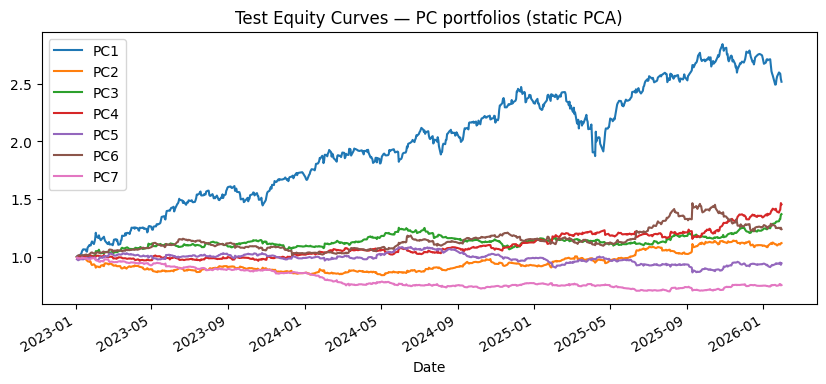

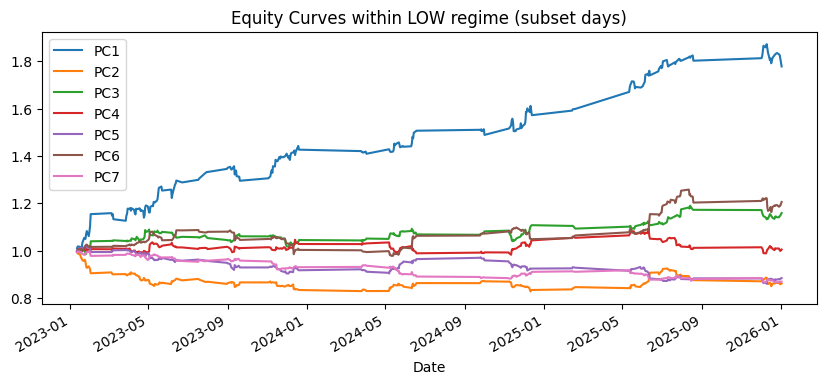

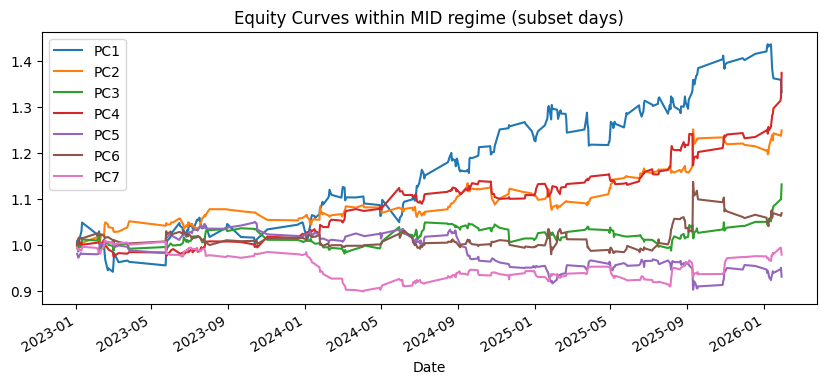

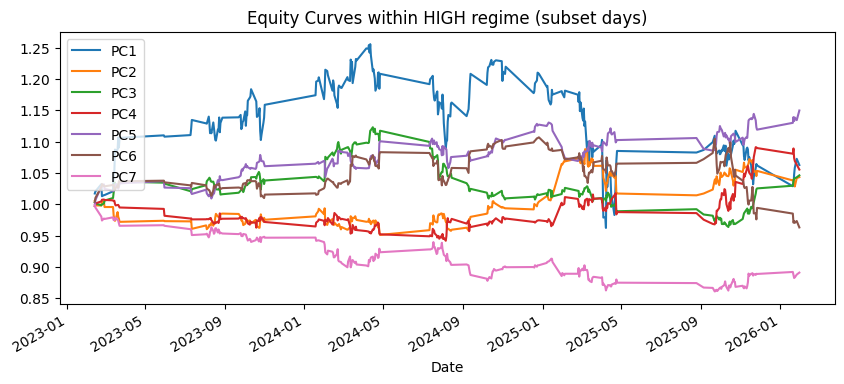

In [6]:
((1+F_test.iloc[:, :7]).cumprod()).plot(title="Test Equity Curves — PC portfolios (static PCA)")
plt.show()

for rn in ["LOW","MID","HIGH"]:
    idx = reg_test[reg_test == rn].index
    cols = F_test.columns[:7]
    ((1+F_test.loc[idx, cols]).cumprod()).plot(title=f"Equity Curves within {rn} regime (subset days)")
    plt.show()


### Bootstrap block-length calibration
Use a liquid benchmark (QQQ) to choose a reasonable stationary-bootstrap block length before running the uncertainty analysis.


In [7]:
# ============================================================
# Bootstrap block-length calibration (QQQ benchmark)
# ============================================================

px_B = download("QQQ", start=START, end=END, auto_adjust=False, progress=False)["Adj Close"].dropna(how="all")
B_ret = linear_returns_from_prices(px_B)

if isinstance(B_ret, pd.DataFrame):
    B_ret = B_ret.iloc[:, 0]
elif isinstance(B_ret, np.ndarray) and B_ret.ndim == 2 and B_ret.shape[1] == 1:
    B_ret = B_ret[:, 0]
B_ret = pd.Series(B_ret).dropna().astype(float)

res_abs = choose_block_length_by_acf_matching(
    B_ret.abs(),
    candidates=[5, 10, 15, 20, 30],
    nlags=30,
    n_boot=300,
    use_abs=True,
    seed=1,
    stationary_bootstrap_indices_fn=stationary_bootstrap_indices,
    distance="weighted",
)
print("ACF-matching best L on |QQQ returns|:", res_abs["best_L"])
display(res_abs["scores"])

L_pw = politis_white_block_length(B_ret, use_abs=True)
print("Politis–White suggested mean block length:", L_pw)


ACF-matching best L on |QQQ returns|: 30


,0
5,0.050518
10,0.036840
15,0.028579
20,0.024466
30,0.018477


Politis–White suggested mean block length: 39


## 4) Stationary bootstrap (Politis–Romano) for uncertainty of metrics
Bootstrap jointly (PC returns + state variable) by resampling time indices, preserving dependence.


In [8]:
# ============================================================
# Bootstrap CIs — ALL selected PCs (first 7) and key metrics
# (Politis–Romano stationary bootstrap)
# ============================================================

PCS = [c for c in F_test.columns if c.startswith("PC")][:7]
KEYS = ["CAGR", "CAGR_excess", "ShR", "SoR", "Calmar", "Martin", "MxDD"]

df_joint = pd.concat(
    [
        F_test[PCS],
        z_daily.reindex(F_test.index).rename("z"),
        rf_daily_hist.reindex(F_test.index).rename("rf"),
    ],
    axis=1,
).dropna()
print("Joint test shape:", df_joint.shape)
print(f"Bootstrap metrics use historical RF proxy {rf_source_used} for Sharpe / Sortino / Martin and excess CAGR.")

N_BOOT = 1000
AVG_BLOCK = L_pw
sims = stationary_bootstrap_series(df_joint.reset_index(drop=True), n_boot=N_BOOT, avg_block_len=AVG_BLOCK, seed=1)

for key in KEYS:
    print("\n====================", key, "====================")
    for regime_name in ["overall","LOW","MID","HIGH"]:
        display(bootstrap_ci_table(key, regime_name).head(10))


Joint test shape: (772, 9)
Bootstrap metrics use historical RF proxy ^IRX for Sharpe / Sortino / Martin and excess CAGR.

==================== CAGR ====================


,mean,p05,p50,p95,n
PC,,,,,
PC1,0.358083,0.156002,0.352495,0.576578,1000
PC4,0.131958,0.052321,0.128497,0.226254,1000
PC3,0.109162,0.002345,0.105475,0.230861,1000
PC6,0.074702,-0.047972,0.070669,0.208609,1000
PC2,0.038617,-0.057079,0.035820,0.140812,1000
PC5,-0.016726,-0.087465,-0.017002,0.062250,1000
PC7,-0.086220,-0.151838,-0.086394,-0.019249,1000


,mean,p05,p50,p95,n
PC,,,,,
PC1,0.711017,0.384884,0.691593,1.097966,1000
PC6,0.175602,-0.095837,0.171557,0.458024,1000
PC3,0.141144,-0.015364,0.136409,0.324201,1000
PC4,0.027541,-0.123857,0.020682,0.197370,1000
PC5,-0.092826,-0.209328,-0.098205,0.040344,1000
PC2,-0.097242,-0.278855,-0.106199,0.115808,1000
PC7,-0.123260,-0.211420,-0.126835,-0.025828,1000


,mean,p05,p50,p95,n
PC,,,,,
PC1,0.380830,0.056203,0.375123,0.732290,1000
PC4,0.301753,0.076220,0.292925,0.558772,1000
PC2,0.234773,0.040830,0.225110,0.451082,1000
PC3,0.143435,-0.037549,0.134400,0.360077,1000
PC6,0.114600,-0.062856,0.099931,0.342076,1000
PC7,-0.057460,-0.212617,-0.055661,0.097693,1000
PC5,-0.083401,-0.220851,-0.080468,0.059036,1000


,mean,p05,p50,p95,n
PC,,,,,
PC5,0.145499,0.000325,0.141468,0.287815,1000
PC4,0.100431,-0.055815,0.087784,0.300664,1000
PC1,0.098966,-0.259618,0.086954,0.512664,1000
PC3,0.060477,-0.157332,0.047560,0.289515,1000
PC2,0.020310,-0.118231,0.009478,0.177820,1000
PC6,-0.034836,-0.196574,-0.044188,0.149928,1000
PC7,-0.070344,-0.177693,-0.076927,0.059048,1000


...


==================== MxDD ====================


,mean,p05,p50,p95,n
PC,,,,,
PC4,-0.078201,-0.112674,-0.074860,-0.054485,1000
PC3,-0.120650,-0.199573,-0.112212,-0.070884,1000
PC2,-0.159218,-0.269652,-0.150329,-0.082184,1000
PC6,-0.172358,-0.282942,-0.165965,-0.090321,1000
PC5,-0.189995,-0.305152,-0.181461,-0.099791,1000
PC1,-0.200647,-0.302630,-0.200314,-0.109840,1000
PC7,-0.280299,-0.416446,-0.281803,-0.140211,1000


,mean,p05,p50,p95,n
PC,,,,,
PC1,-0.058456,-0.087077,-0.056160,-0.038272,1000
PC3,-0.067812,-0.109104,-0.063376,-0.042827,1000
PC4,-0.092629,-0.168105,-0.084495,-0.043656,1000
PC6,-0.105196,-0.182818,-0.097569,-0.054631,1000
PC5,-0.145839,-0.229066,-0.142981,-0.072688,1000
PC7,-0.147900,-0.224613,-0.147275,-0.071233,1000
PC2,-0.182768,-0.311122,-0.177062,-0.075936,1000


,mean,p05,p50,p95,n
PC,,,,,
PC2,-0.056945,-0.091530,-0.052883,-0.035635,1000
PC4,-0.059306,-0.094234,-0.057414,-0.032492,1000
PC3,-0.066593,-0.113544,-0.061132,-0.036269,1000
PC6,-0.083959,-0.135660,-0.079712,-0.049209,1000
PC1,-0.110226,-0.175575,-0.104111,-0.062249,1000
PC7,-0.127981,-0.234090,-0.121585,-0.051830,1000
PC5,-0.149004,-0.252776,-0.143040,-0.069718,1000


,mean,p05,p50,p95,n
PC,,,,,
PC5,-0.059923,-0.095727,-0.055332,-0.035607,1000
PC4,-0.069161,-0.118976,-0.063260,-0.036264,1000
PC2,-0.097411,-0.170081,-0.090174,-0.049582,1000
PC3,-0.102470,-0.207600,-0.092057,-0.040900,1000
PC7,-0.121504,-0.205388,-0.116186,-0.053695,1000
PC6,-0.137906,-0.243496,-0.131542,-0.054281,1000
PC1,-0.199769,-0.360059,-0.188008,-0.097057,1000


## 5) Build the investable principal-portfolio baseline

This section creates the **implementation-aware walk-forward PCA baseline** used later by the overlay blocks.

Outputs from here provide the core objects for the rest of the notebook:
- walk-forward factor returns,
- time-varying principal-portfolio weights,
- and spread-based cost proxies for net evaluation.


In [9]:
# ============================================================
# Corwin–Schultz helpers (single asset + panel + one-way cost)
# ============================================================

def corwin_schultz_spread(high: pd.Series, low: pd.Series) -> pd.Series:
    """
    Corwin–Schultz (2012) bid–ask spread estimator from daily high/low prices.
    Returns the FULL proportional spread, e.g. 0.01 = 1%.
    Input must be two aligned Series for ONE asset.
    """
    high = pd.Series(high).astype(float)
    low = pd.Series(low).astype(float)

    idx = high.dropna().index.intersection(low.dropna().index)
    high = high.loc[idx].sort_index()
    low = low.loc[idx].sort_index()

    hl = np.log(high / low)
    beta = hl.pow(2) + hl.shift(1).pow(2)

    high2 = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    low2 = pd.concat([low, low.shift(1)], axis=1).min(axis=1)
    gamma = np.log(high2 / low2).pow(2)

    k = 3 - 2 * np.sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    alpha = alpha.clip(lower=0)

    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    spread.name = "cs_spread"
    return spread


def corwin_schultz_panel(
    px_high: pd.DataFrame,
    px_low: pd.DataFrame,
    tickers: list | None = None,
    clip_upper: float | None = 0.10,
) -> pd.DataFrame:
    """
    Apply Corwin–Schultz asset by asset on a panel of highs/lows.
    Returns a DataFrame indexed by date, columns=tickers, with FULL spreads.
    """
    px_high = px_high.copy()
    px_low = px_low.copy()

    if tickers is None:
        tickers = [c for c in px_high.columns if c in px_low.columns]

    out = {}
    for t in tickers:
        h = px_high[t].dropna()
        l = px_low[t].dropna()

        idx = h.index.intersection(l.index)
        if len(idx) < 3:
            out[t] = pd.Series(dtype=float)
            continue

        s = corwin_schultz_spread(h.loc[idx], l.loc[idx])

        if clip_upper is not None:
            s = s.clip(upper=clip_upper)

        out[t] = s

    panel = pd.DataFrame(out).sort_index()
    panel = panel.reindex(columns=tickers)
    return panel


def cs_panel_to_one_way_cost(cs_spreads: pd.DataFrame) -> pd.DataFrame:
    """
    Convert FULL spread to ONE-WAY implementation cost.
    If spread = ask-bid over mid, a one-way execution cost is half-spread.
    """
    return 0.5 * cs_spreads.astype(float)

In [10]:
# ============================================================
# Walk-forward PCA with:
# - sign alignment vs previous rebalance
# - flat bps OR asset-level time-varying costs
# - cost charged on first realized return of each segment
# ============================================================

def add_months(ts: pd.Timestamp, m: int) -> pd.Timestamp:
    return (pd.Timestamp(ts) + pd.offsets.DateOffset(months=m)).normalize()


def _align_W_to_prev(W_prev: pd.DataFrame | None, W_now: pd.DataFrame) -> pd.DataFrame:
    """
    Align PC signs to previous rebalance so that sign flips do not create fake turnover.
    """
    if W_prev is None:
        return W_now.copy()

    W_aligned = W_now.copy()
    common_cols = [c for c in W_now.columns if c in W_prev.columns]

    for c in common_cols:
        a = W_prev[c].values.astype(float)
        b = W_now[c].values.astype(float)

        if np.dot(a, b) < 0:
            W_aligned[c] = -W_aligned[c]

    return W_aligned


def walk_forward_pca(
    R: pd.DataFrame,
    start_test: str,
    train_years: int = 5,
    step_months: int = 3,
    k: int = 7,
    gross_norm: float = 1.0,
    tc_bps: float | None = 0.0,
    asset_costs: pd.DataFrame | None = None,
    charge_initial_rebalance: bool = False,
):
    """
    Walk-forward PCA with either:
      1) flat linear transaction cost in bps via tc_bps
      2) asset-level time-varying one-way costs via asset_costs (date x asset)

    Cost of each PC at rebalance:
        cost_pc_t = sum_i one_way_cost_{i,t} * |Δw_{i,t}|

    Cost is charged on the first realized return in each out-of-sample segment.
    """

    R = R.dropna().sort_index().copy()
    t0 = pd.Timestamp(start_test)
    t_end = R.index.max()

    if asset_costs is not None:
        asset_costs = (
            asset_costs.reindex(index=R.index, columns=R.columns)
            .sort_index()
            .ffill()
            .fillna(0.0)
            .astype(float)
        )

    weights_hist = []
    f_all = []
    costs_all = []
    W_prev = None

    reb = t0
    while True:
        train_start = reb - pd.DateOffset(years=train_years)
        train_end = reb - pd.DateOffset(days=1)
        test_start = reb
        test_end = add_months(reb, step_months) - pd.DateOffset(days=1)

        if test_start > t_end:
            break

        R_train = R.loc[train_start:train_end]
        R_test = R.loc[test_start:test_end]

        if len(R_train) < 252 or len(R_test) < 5:
            reb = add_months(reb, step_months)
            continue

        mu, Sigma = weighted_mean_cov(R_train)
        lam, V, vol, rho = correlation_pca(Sigma.values)

        W = pc_portfolio_weights_from_corr_pca(V[:, :k], vol, gross_norm=gross_norm)
        W.index = R.columns
        W.columns = [f"PC{i+1}" for i in range(W.shape[1])]

        # Critical: align signs to previous rebalance BEFORE turnover/costs/returns comparison
        W = _align_W_to_prev(W_prev, W)

        f = factor_returns(R_test, W)
        f_all.append(f)

        seg_cost = pd.DataFrame(0.0, index=R_test.index, columns=f.columns)

        if charge_initial_rebalance or (W_prev is not None):
            dW = W.abs() if W_prev is None else (W - W_prev).abs()

            # first ACTUAL trading day in the segment
            trade_date = R_test.index[0]

            if asset_costs is not None:
                c_assets = asset_costs.loc[trade_date, R.columns]
                c_pc = dW.mul(c_assets, axis=0).sum(axis=0)
            else:
                c = 0.0 if tc_bps is None else float(tc_bps) / 1e4
                c_pc = dW.sum(axis=0) * c

            seg_cost.iloc[0, :] = c_pc.reindex(f.columns).values

        costs_all.append(seg_cost)
        W_prev = W.copy()

        weights_hist.append(
            {
                "rebalance": reb,
                "train_start": train_start,
                "train_end": train_end,
                "W": W.copy(),
            }
        )

        reb = add_months(reb, step_months)

    F = pd.concat(f_all).sort_index() if f_all else pd.DataFrame()
    C = pd.concat(costs_all).sort_index() if costs_all else pd.DataFrame(0.0, index=F.index, columns=F.columns)

    C = C.reindex(index=F.index, columns=F.columns).fillna(0.0)
    F_net = F - C

    return F, F_net, weights_hist

One-way cost summary (bps) by asset:


,mean,50%,max
Ticker,,,
AMZN,23.152199,0.000000,309.037734
AAPL,20.411990,0.164135,310.200539
IBM,18.487273,0.691862,435.367525
GOOGL,22.385419,3.197547,290.934172
CSCO,20.399839,5.304270,357.011457
NVDA,37.172881,5.343990,510.791178
MSFT,21.326334,5.582481,401.975764
META,27.023261,5.624223,313.026737
ORCL,22.373959,5.679730,618.703691


WF factor returns shape: (772, 7)  | net: (772, 7)


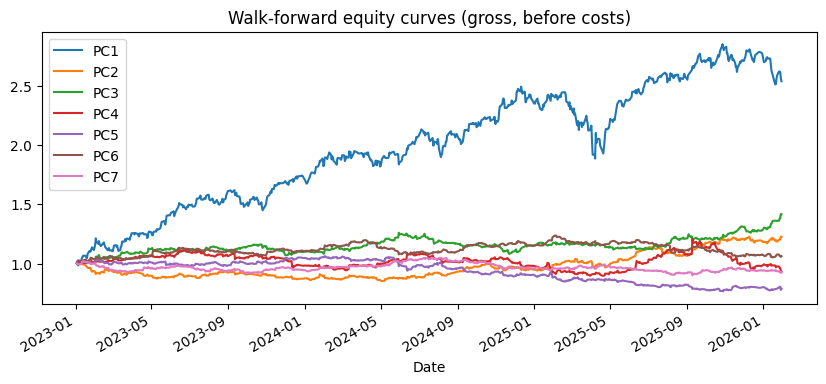

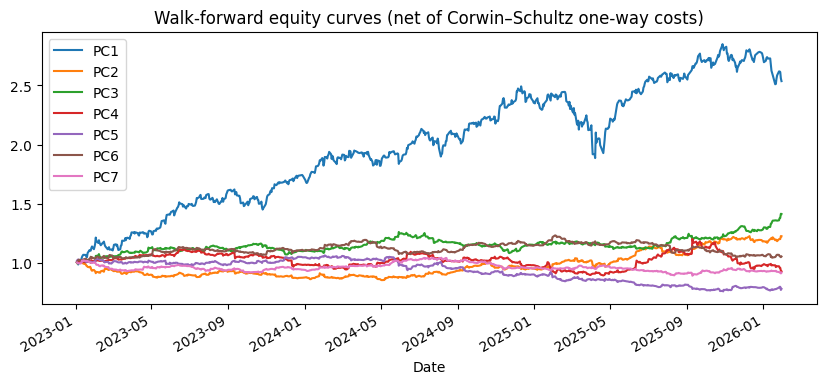

Walk-forward metrics: Sharpe / Sortino / Martin use historical RF proxy ^IRX.

--- CAGR (gross) ---


regime,HIGH,LOW,MID,overall
PC,,,,
PC1,0.064640,0.799277,0.315874,0.355357
PC2,0.052024,-0.137709,0.331972,0.069242
PC3,0.052871,0.133923,0.178345,0.120525
PC4,-0.066381,0.168926,-0.135498,-0.022143
PC5,-0.063602,-0.027790,-0.127412,-0.074715
PC6,0.022796,0.086036,-0.040830,0.020212
PC7,0.027144,0.017629,-0.107858,-0.023934


--- CAGR (net of CS costs) ---


regime,HIGH,LOW,MID,overall
PC,,,,
PC1,0.064218,0.799022,0.315738,0.355067
PC2,0.050757,-0.138285,0.331637,0.068486
PC3,0.051576,0.132435,0.177782,0.119404
PC4,-0.069293,0.167141,-0.136605,-0.024079
PC5,-0.068560,-0.031696,-0.128770,-0.078055
PC6,0.018846,0.081781,-0.042146,0.017118
PC7,0.020963,0.013168,-0.110293,-0.028200



--- CAGR_excess (gross) ---


...

regime,HIGH,LOW,MID,overall
PC,,,,
PC1,0.191693,56.142164,8.920290,6.102601
PC2,0.121562,-1.537492,19.437158,0.266206
PC3,0.076336,2.924109,5.675254,1.267199
PC4,-2.220464,3.071290,-1.676943,-0.689110
PC5,-1.470706,-0.962481,-2.169798,-0.842521
PC6,-0.884741,1.022424,-1.686070,-0.469308
PC7,-0.972254,-1.095106,-1.996183,-0.968745



--- MxDD (gross) ---


regime,HIGH,LOW,MID,overall
PC,,,,
PC1,-0.236461,-0.048420,-0.103610,-0.243113
PC2,-0.085788,-0.159628,-0.043995,-0.152217
PC3,-0.123259,-0.074251,-0.055106,-0.141680
PC4,-0.156917,-0.102964,-0.173593,-0.226787
PC5,-0.133170,-0.160979,-0.156147,-0.280115
PC6,-0.060985,-0.067735,-0.147153,-0.149884
PC7,-0.060114,-0.071631,-0.134736,-0.141291


--- MxDD (net of CS costs) ---


regime,HIGH,LOW,MID,overall
PC,,,,
PC1,-0.236649,-0.048439,-0.103610,-0.243331
PC2,-0.086645,-0.159902,-0.044110,-0.152451
PC3,-0.123832,-0.074251,-0.055112,-0.142173
PC4,-0.159359,-0.102964,-0.174698,-0.227526
PC5,-0.137905,-0.161633,-0.157517,-0.286727
PC6,-0.062207,-0.070267,-0.147153,-0.153085
PC7,-0.061792,-0.072672,-0.137201,-0.145653


In [11]:
# ============================================================
# Time-varying transaction costs from Corwin–Schultz spreads
# ============================================================

# Full bid-ask spreads estimated asset by asset
cs_spreads = corwin_schultz_panel(
    px_high=px_high,
    px_low=px_low,
    tickers=list(R.columns),
    clip_upper=None,
)

# Convert full spread to one-way implementation cost
asset_costs = (
    cs_panel_to_one_way_cost(cs_spreads)
    .reindex(index=R.index, columns=R.columns)
    .ffill()
    .fillna(0.0)
)

print("One-way cost summary (bps) by asset:")
display((1e4 * asset_costs).describe().T[["mean", "50%", "max"]].sort_values("50%"))

F_wf, F_wf_net, W_hist = walk_forward_pca(
    R=R,
    start_test=TEST_START_DEFAULT,
    train_years=WF_TRAIN_YEARS,
    step_months=WF_STEP_MONTHS,
    k=WF_K_CHOICE,
    gross_norm=GROSS_NORM,
    tc_bps=None,
    asset_costs=asset_costs,
    charge_initial_rebalance=False,
)

print("WF factor returns shape:", F_wf.shape, " | net:", F_wf_net.shape)

PCS_WF = [c for c in F_wf.columns if c.startswith("PC")][:7]

if not F_wf.empty:
    ((1 + F_wf[PCS_WF]).cumprod()).plot(title="Walk-forward equity curves (gross, before costs)")
    plt.show()

    ((1 + F_wf_net[PCS_WF]).cumprod()).plot(
        title="Walk-forward equity curves (net of Corwin–Schultz one-way costs)"
    )
    plt.show()

    reg_wf = reg.reindex(F_wf.index)
    rf_wf = rf_daily_hist.reindex(F_wf.index).ffill().fillna(0.0)

    m_wf_g = {"overall": {c: perf_metrics(F_wf[c], rf_daily=rf_wf) for c in PCS_WF}}
    m_wf_n = {"overall": {c: perf_metrics(F_wf_net[c], rf_daily=rf_wf) for c in PCS_WF}}

    for rn in ["LOW", "MID", "HIGH"]:
        idx = reg_wf[reg_wf == rn].index
        m_wf_g[rn] = {c: perf_metrics(F_wf.loc[idx, c], rf_daily=rf_wf) for c in PCS_WF}
        m_wf_n[rn] = {c: perf_metrics(F_wf_net.loc[idx, c], rf_daily=rf_wf) for c in PCS_WF}

    print(f"Walk-forward metrics: Sharpe / Sortino / Martin use historical RF proxy {rf_source_used}.")
    for key in ["CAGR", "CAGR_excess", "ShR", "SoR", "Calmar", "Martin", "MxDD"]:
        print("\n---", key, "(gross) ---")
        display(table_from_metrics(m_wf_g, key))

        print("---", key, "(net of CS costs) ---")
        display(table_from_metrics(m_wf_n, key))


## 6) Exploratory challenger overlays — IV-aware downside models

This block explores a first family of **short-horizon downside-aware overlays** on top of the core **PC1** strategy.

The logic is:

1. use **today’s implied-volatility information** (`log IV`, `Δ log IV`, rolling `z`-score of `log IV`) as predictors;
2. define future downside as the **worst forward return relative to today’s entry wealth** over the next `H` trading days;
3. test whether IV contains useful information about that downside target;
4. translate the signal into a **systematic exposure-scaling overlay** on walk-forward **net** PC1 returns.

These cells are kept because they document the research process, but they should be read as **challenger models / discarded main paths**, not as the final preferred overlay engine.


In [12]:

# ============================================================
# V3 helpers: downside target, IV predictors, exploratory tests,
# and expanding OOS downside overlay on PC1
# ============================================================

def forward_worst_return_from_returns(r: pd.Series, horizon: int = 21) -> pd.Series:
    """
    Worst forward cumulative return relative to today's entry wealth:
        Y_t = min_{1 <= h <= H} (W_{t+h} / W_t - 1)
    where W is the wealth index implied by returns r.
    """
    r = pd.Series(r).dropna().astype(float)
    wealth = (1.0 + r).cumprod()
    w = wealth.values.astype(float)

    out = np.full(len(w), np.nan)
    for i in range(len(w)):
        j = min(len(w), i + horizon + 1)
        if i + 1 >= j:
            continue
        out[i] = np.min(w[i + 1:j] / w[i] - 1.0)

    s = pd.Series(out, index=wealth.index, name=f"worst_fwd_ret_{horizon}d")
    return s


def build_iv_predictor_panel(
    iv_level: pd.Series,
    target_index: pd.Index,
    z_window: int = 252,
    z_min_obs: int = 126,
) -> pd.DataFrame:
    """
    Build minimal IV predictors aligned to a target strategy index.
    Predictors are observed at date t (close):
      - log_iv
      - dlog_iv
      - log_iv_z  (rolling z-score, non-leaky because it only uses data up to t)
    """
    iv = (
        pd.Series(iv_level)
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .reindex(target_index)
        .ffill()
    )

    log_iv = np.log(iv)
    dlog_iv = log_iv.diff()

    roll_mean = log_iv.rolling(z_window, min_periods=z_min_obs).mean()
    roll_std = log_iv.rolling(z_window, min_periods=z_min_obs).std(ddof=1).replace(0.0, np.nan)
    log_iv_z = (log_iv - roll_mean) / roll_std

    out = pd.DataFrame(
        {
            "log_iv": log_iv,
            "dlog_iv": dlog_iv,
            "log_iv_z": log_iv_z,
        },
        index=target_index,
    )
    return out


def bucket_summary(
    df: pd.DataFrame,
    feature: str,
    target: str,
    event: str,
    q: int = 5,
) -> pd.DataFrame:
    """
    Exploratory monotonicity check by feature quantile bucket.
    """
    tmp = df[[feature, target, event]].dropna().copy()
    if len(tmp) == 0:
        return pd.DataFrame()

    tmp["bucket"] = pd.qcut(tmp[feature], q=q, duplicates="drop")
    out = tmp.groupby("bucket", observed=False).agg(
        n=(target, "size"),
        feature_mean=(feature, "mean"),
        target_mean=(target, "mean"),
        target_median=(target, "median"),
        target_p10=(target, lambda x: x.quantile(0.10)),
        event_rate=(event, "mean"),
    )
    return out


def hac_ols_summary(
    y: pd.Series,
    X: pd.DataFrame,
    hac_lags: int = 21,
):
    """
    OLS with HAC (Newey-West) standard errors for overlapping forward targets.
    """
    try:
        import statsmodels.api as sm
    except Exception as e:
        print("statsmodels not available for HAC OLS:", e)
        return None, pd.DataFrame()

    df = pd.concat([pd.Series(y, name="y"), X], axis=1).dropna()
    if len(df) < 25:
        return None, pd.DataFrame()

    y_ = df["y"].astype(float)
    X_ = sm.add_constant(df.drop(columns="y").astype(float), has_constant="add")
    res = sm.OLS(y_, X_).fit(cov_type="HAC", cov_kwds={"maxlags": int(hac_lags)})

    table = pd.DataFrame(
        {
            "coef": res.params,
            "tstat_HAC": res.tvalues,
            "pvalue_HAC": res.pvalues,
        }
    )
    return res, table


def _standardize_train_now(X_train: pd.DataFrame, x_now: pd.Series):
    """
    Standardize predictors using training-sample moments only.
    """
    mu = X_train.mean(axis=0)
    sd = X_train.std(axis=0, ddof=0).replace(0.0, 1.0)
    Xs = (X_train - mu) / sd
    xs = (pd.Series(x_now, index=X_train.columns) - mu) / sd
    return Xs, xs


def _fit_predict_logit_prob(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    x_now: pd.Series,
) -> float:
    """
    Robust probability forecast for downside event:
    prefers sklearn logistic regression; falls back to statsmodels GLM.
    """
    X_train = pd.DataFrame(X_train).astype(float)
    y_train = pd.Series(y_train).astype(int)
    x_now = pd.Series(x_now, index=X_train.columns).astype(float)

    Xs, xs = _standardize_train_now(X_train, x_now)

    if y_train.nunique() < 2:
        return float(y_train.mean())

    try:
        from sklearn.linear_model import LogisticRegression

        clf = LogisticRegression(
            C=1.0,
            solver="lbfgs",
            max_iter=2000,
        )
        clf.fit(Xs.values, y_train.values)
        p = clf.predict_proba(xs.values.reshape(1, -1))[0, 1]
        return float(p)

    except Exception:
        try:
            import statsmodels.api as sm

            Xc = sm.add_constant(Xs, has_constant="add")
            xc = sm.add_constant(xs.to_frame().T, has_constant="add")
            model = sm.GLM(y_train.values, Xc.values, family=sm.families.Binomial())
            res = model.fit()
            p = float(res.predict(xc.values)[0])
            return float(p)
        except Exception:
            return float(y_train.mean())


def prob_to_exposure(
    p: float,
    exposure_map: list[tuple[float, float]] | None = None,
) -> float:
    """
    Map downside-event probability to a gross exposure multiplier.
    exposure_map is a sorted list of (probability_cap, exposure).
    """
    if exposure_map is None:
        exposure_map = [
            (0.10, 1.00),
            (0.20, 0.75),
            (0.35, 0.50),
            (np.inf, 0.25),
        ]

    if not np.isfinite(p):
        return 1.0

    for cap, exp_ in exposure_map:
        if p <= cap:
            return float(exp_)
    return float(exposure_map[-1][1])


def expanding_downside_overlay(
    base_r: pd.Series,
    X: pd.DataFrame,
    downside_target: pd.Series,
    downside_threshold: float = -0.05,
    horizon: int = 21,
    min_train: int = 252,
    refit_every: int = 21,
    exposure_map: list[tuple[float, float]] | None = None,
    overlay_cost_bps: float = 0.0,
):
    """
    Expanding-window OOS overlay:
    - at date t, estimate P(Y_t < threshold | X_t) using only observations s
      whose forward target is fully known by t (non-leaky training end = t-horizon)
    - map that probability into an exposure multiplier
    - apply the exposure from the NEXT daily return onward

    Returns a dict with:
      overlay_returns, probability, exposure_signal, exposure_applied, diagnostics
    """
    base_r = pd.Series(base_r).dropna().astype(float)
    X = pd.DataFrame(X).reindex(base_r.index)
    y = pd.Series(downside_target).reindex(base_r.index)
    event = (y < downside_threshold).astype(float)

    df = pd.concat(
        [base_r.rename("base_r"), X, y.rename("target"), event.rename("event")],
        axis=1,
    ).dropna(subset=["base_r"] + list(X.columns))

    p_hat = pd.Series(np.nan, index=df.index, name="p_downside")
    exposure_signal = pd.Series(np.nan, index=df.index, name="exposure_signal")

    last_fit_i = None
    cached_train = None

    for i, ts in enumerate(df.index):
        train_end_i = i - horizon
        if train_end_i < 0:
            continue

        train_df = df.iloc[: train_end_i + 1].dropna(subset=list(X.columns) + ["target", "event"])
        if len(train_df) < min_train:
            continue

        y_train = train_df["event"].astype(int)
        X_train = train_df[X.columns].astype(float)

        if y_train.nunique() < 2:
            p = float(y_train.mean())
        else:
            should_refit = (
                (cached_train is None)
                or (last_fit_i is None)
                or ((i - last_fit_i) >= refit_every)
            )
            if should_refit:
                cached_train = (X_train.copy(), y_train.copy())
                last_fit_i = i

            p = _fit_predict_logit_prob(
                X_train=cached_train[0],
                y_train=cached_train[1],
                x_now=df.loc[ts, X.columns],
            )

        p_hat.loc[ts] = p
        exposure_signal.loc[ts] = prob_to_exposure(p, exposure_map=exposure_map)

    # Signal observed at close t -> exposure applied from next daily return onward.
    exposure_applied = exposure_signal.shift(1).reindex(base_r.index).ffill().fillna(1.0)
    overlay_turnover = exposure_applied.diff().abs().fillna(0.0)
    overlay_cost = (float(overlay_cost_bps) / 1e4) * overlay_turnover

    overlay_r = exposure_applied * base_r - overlay_cost
    overlay_r.name = f"{base_r.name}_overlay" if base_r.name is not None else "overlay_returns"

    diagnostics = pd.concat(
        [
            base_r.rename("base_r"),
            y.rename("target"),
            event.rename("event"),
            p_hat.reindex(base_r.index),
            exposure_signal.reindex(base_r.index),
            exposure_applied.rename("exposure_applied"),
            overlay_turnover.rename("overlay_turnover"),
            overlay_cost.rename("overlay_cost"),
            overlay_r.rename("overlay_r"),
        ],
        axis=1,
    )

    return {
        "overlay_returns": overlay_r,
        "probability": p_hat.reindex(base_r.index),
        "exposure_signal": exposure_signal.reindex(base_r.index),
        "exposure_applied": exposure_applied,
        "diagnostics": diagnostics,
    }


def compare_strategy_metrics(
    strategies: dict[str, pd.Series],
    rf_daily: float | pd.Series | None = 0.0,
    ann: int = 252,
) -> pd.DataFrame:
    """
    Compact comparison table for strategy return series.
    """
    rows = {}
    for name, r in strategies.items():
        rows[name] = perf_metrics(pd.Series(r).dropna(), rf_daily=rf_daily, ann=ann)

    out = pd.DataFrame(rows).T[
        ["n", "CAGR", "CAGR_excess", "ShR", "SoR", "Calmar", "Martin", "MxDD", "Ulcer"]
    ]
    return out


V3 sample shape: (646, 6)
Downside event rate: 5.11 %


,pc1_base,worst_fwd_ret,log_iv,dlog_iv,log_iv_z,event_dd
Date,,,,,,
2023-07-05,0.004343,-0.011955,2.991222,0.002011,-1.196130,0
2023-07-06,-0.009699,-0.002279,3.049747,0.058525,-0.741528,0
2023-07-07,-0.002279,0.002082,3.025291,-0.024456,-0.923175,0
2023-07-10,0.002082,0.009225,3.048325,0.023034,-0.741154,0
2023-07-11,0.009225,0.010688,3.039749,-0.008576,-0.802258,0



Bucket summary by log IV


,n,feature_mean,target_mean,target_median,target_p10,event_rate
bucket,,,,,,
"(2.608, 2.865]",131,2.811776,-0.029427,-0.025806,-0.063371,0.022901
"(2.865, 2.951]",128,2.913875,-0.029549,-0.017657,-0.090602,0.054688
"(2.951, 3.024]",129,2.986946,-0.032685,-0.026191,-0.077519,0.015504
"(3.024, 3.121]",129,3.072448,-0.029816,-0.023030,-0.071747,0.031008
"(3.121, 3.767]",129,3.256595,-0.031053,-0.017346,-0.121522,0.131783



Bucket summary by Δ log IV


,n,feature_mean,target_mean,target_median,target_p10,event_rate
bucket,,,,,,
"(-0.20400000000000001, -0.0406]",130,-0.072033,-0.027952,-0.019352,-0.074546,0.038462
"(-0.0406, -0.0123]",129,-0.025393,-0.031107,-0.018948,-0.093336,0.069767
"(-0.0123, 0.00702]",129,-0.002766,-0.028850,-0.025154,-0.067200,0.046512
"(0.00702, 0.0337]",129,0.019318,-0.034532,-0.024454,-0.084474,0.054264
"(0.0337, 0.352]",129,0.082022,-0.030099,-0.024284,-0.071693,0.046512



HAC OLS (worst forward return ~ IV predictors)


,coef,tstat_HAC,pvalue_HAC
const,-0.031769,-0.400281,0.688949
log_iv,0.000421,0.015576,0.987573
dlog_iv,-0.015983,-0.642535,0.520526



Strategy comparison (base walk-forward NET PC1 vs IV overlay); RF proxy = ^IRX


,n,CAGR,CAGR_excess,ShR,SoR,Calmar,Martin,MxDD,Ulcer
PC1_wf_net,772.000000,0.355067,0.294873,1.329937,2.227498,1.459195,6.102601,-0.243331,0.050558
PC1_wf_net_overlay,772.000000,0.355067,0.294873,1.329937,2.227498,1.459195,6.102601,-0.243331,0.050558


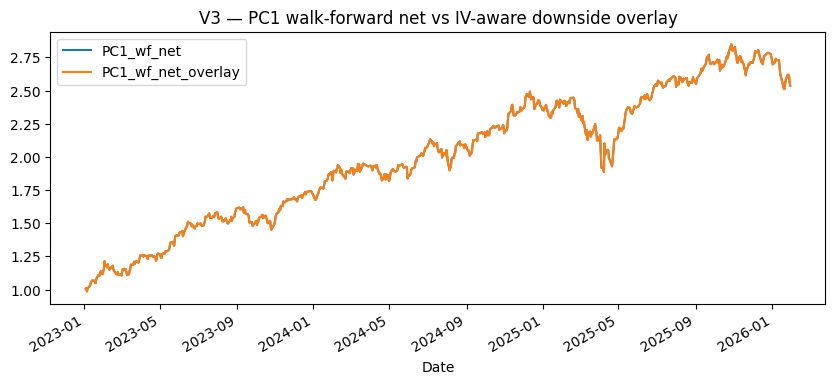

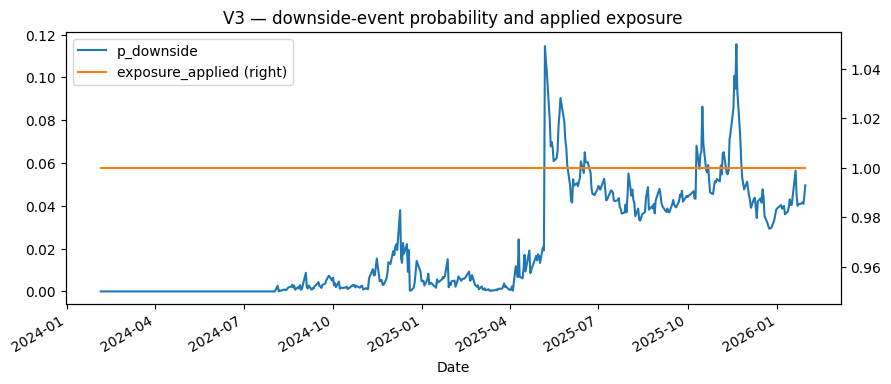

,base_r,target,event,p_downside,exposure_signal,exposure_applied,overlay_turnover,overlay_cost,overlay_r
Date,,,,,,,,,
2026-01-16,-0.007245,-0.030103,0.000000,0.040516,1.000000,1.000000,0.000000,0.000000,-0.007245
2026-01-20,-0.030103,0.001152,0.000000,0.056452,1.000000,1.000000,0.000000,0.000000,-0.030103
2026-01-21,0.001152,0.009423,0.000000,0.044987,1.000000,1.000000,0.000000,0.000000,0.001152
2026-01-22,0.017324,-0.007767,0.000000,0.039985,1.000000,1.000000,0.000000,0.000000,0.017324
2026-01-23,0.011223,-0.018780,0.000000,0.040783,1.000000,1.000000,0.000000,0.000000,0.011223
2026-01-26,0.012959,-0.031332,0.000000,0.041084,1.000000,1.000000,0.000000,0.000000,0.012959
2026-01-27,-0.000150,-0.031187,0.000000,0.041552,1.000000,1.000000,0.000000,0.000000,-0.000150
2026-01-28,-0.001674,-0.029563,0.000000,0.040906,1.000000,1.000000,0.000000,0.000000,-0.001674
2026-01-29,-0.020786,-0.008964,0.000000,0.044948,1.000000,1.000000,0.000000,0.000000,-0.020786


In [13]:

# ============================================================
# V3 example: IV-aware downside overlay on walk-forward NET PC1
# ============================================================

PC_CORE = "PC1"
H_DOWNSIDE = 21          # maturity-matched monthly horizon (approx. 1 month)
DD_THRESHOLD = -0.1     # event = worst forward return below -5%
MIN_TRAIN_DAYS = 252     # expanding OOS estimation window
REFIT_EVERY = 21         # monthly refit cadence

pc1_base = F_wf_net[PC_CORE].dropna().astype(float).copy()
pc1_base.name = f"{PC_CORE}_wf_net"

iv_X = build_iv_predictor_panel(
    iv_level=iv,
    target_index=pc1_base.index,
    z_window=252,
    z_min_obs=126,
)

y_down = forward_worst_return_from_returns(pc1_base, horizon=H_DOWNSIDE)
df_v3 = pd.concat(
    [
        pc1_base.rename("pc1_base"),
        y_down.rename("worst_fwd_ret"),
        iv_X,
    ],
    axis=1,
).dropna()

df_v3["event_dd"] = (df_v3["worst_fwd_ret"] < DD_THRESHOLD).astype(int)

print("V3 sample shape:", df_v3.shape)
print("Downside event rate:", round(100 * df_v3["event_dd"].mean(), 2), "%")
display(df_v3.head())

print("\nBucket summary by log IV")
display(bucket_summary(df_v3, feature="log_iv", target="worst_fwd_ret", event="event_dd", q=5))

print("\nBucket summary by Δ log IV")
display(bucket_summary(df_v3, feature="dlog_iv", target="worst_fwd_ret", event="event_dd", q=5))

ols_res, ols_tab = hac_ols_summary(
    y=df_v3["worst_fwd_ret"],
    X=df_v3[["log_iv", "dlog_iv"]],
    hac_lags=H_DOWNSIDE,
)
print("\nHAC OLS (worst forward return ~ IV predictors)")
display(ols_tab)

overlay_res = expanding_downside_overlay(
    base_r=pc1_base,
    X=iv_X[["log_iv", "dlog_iv"]],
    downside_target=y_down,
    downside_threshold=DD_THRESHOLD,
    horizon=H_DOWNSIDE,
    min_train=MIN_TRAIN_DAYS,
    refit_every=REFIT_EVERY,
    exposure_map=[
    (0.15, 1.00),
    (0.22, 0.90),
    (0.30, 0.75),
    (np.inf, 0.50),
],
    overlay_cost_bps=0.0,   # optional extension: add explicit overlay trading cost
)

pc1_overlay = overlay_res["overlay_returns"].dropna()
diag_v3 = overlay_res["diagnostics"].dropna(how="all")

rf_v3 = rf_daily_hist.reindex(pc1_base.index).ffill().fillna(0.0)

print(f"\nStrategy comparison (base walk-forward NET PC1 vs IV overlay); RF proxy = {rf_source_used}")
display(
    compare_strategy_metrics(
        {
            "PC1_wf_net": pc1_base,
            "PC1_wf_net_overlay": pc1_overlay,
        },
        rf_daily=rf_v3,
    )
)

eq_v3 = pd.concat(
    [
        (1.0 + pc1_base).cumprod().rename("PC1_wf_net"),
        (1.0 + pc1_overlay).cumprod().rename("PC1_wf_net_overlay"),
    ],
    axis=1,
).dropna()

eq_v3.plot(title="V3 — PC1 walk-forward net vs IV-aware downside overlay")
plt.show()

diag_plot = diag_v3[["p_downside", "exposure_applied"]].dropna()
if not diag_plot.empty:
    diag_plot.plot(
        secondary_y=["exposure_applied"],
        title="V3 — downside-event probability and applied exposure",
    )
    plt.show()

display(diag_v3.tail(10))


V3.1 sample shape: (637, 11)
Event rate: 5.18 %


,pc1_base,worst_fwd_ret,rv_fwd,rv_21,dsv_21,usv_21,log_iv,dlog_iv,log_iv_z,event_dd,iv_over_rv
Date,,,,,,,,,,,
2023-07-05,0.004343,-0.011955,0.170823,0.192052,0.126165,0.143285,2.991222,0.002011,-1.196130,0,4.641213
2023-07-06,-0.009699,-0.002279,0.166337,0.196220,0.130562,0.142384,3.049747,0.058525,-0.741528,0,4.678265
2023-07-07,-0.002279,0.002082,0.168019,0.196530,0.130800,0.141850,3.025291,-0.024456,-0.923175,0,4.652229
2023-07-10,0.002082,0.009225,0.172252,0.163192,0.084643,0.142033,3.048325,0.023034,-0.741154,0,4.861151
2023-07-11,0.009225,0.010688,0.178862,0.161086,0.084643,0.138946,3.039749,-0.008576,-0.802258,0,4.865568



Bucket summary by rv_21  ->  worst_fwd_ret / event_dd


,n,feature_mean,target_mean,target_median,target_p10,event_rate
bucket,,,,,,
"(0.0839, 0.147]",128,0.127918,-0.030982,-0.022500,-0.089112,0.023438
"(0.147, 0.169]",127,0.158779,-0.026674,-0.020818,-0.071392,0.031496
"(0.169, 0.191]",127,0.179787,-0.038350,-0.032363,-0.084018,0.039370
"(0.191, 0.208]",127,0.199126,-0.025013,-0.022111,-0.060331,0.015748
"(0.208, 0.591]",128,0.298753,-0.032487,-0.017038,-0.128496,0.148438



Bucket summary by dsv_21  ->  worst_fwd_ret / event_dd


...

,coef,tstat_HAC,pvalue_HAC
const,-0.271556,-1.706421,0.087930
dsv_21,-0.074557,-0.710389,0.477463
log_iv,0.082815,1.567429,0.117015
dlog_iv,-0.018801,-0.884410,0.376475
log_iv_z,-0.010432,-1.199845,0.230200



Expanding OOS logit horse race — downside-event classification


,oos_n,event_rate,mean_p,AUC,Brier
model,,,,,
RV_only,365,0.082192,0.037494,0.133035,0.090200
RV_plus_IV,365,0.082192,0.030875,0.125473,0.088835
DSV_only,365,0.082192,0.022111,0.124527,0.082857
ALL,365,0.082192,0.025341,0.116617,0.086916
DSV_plus_IV,365,0.082192,0.017368,0.116020,0.082430
IV_only,365,0.082192,0.028674,0.112836,0.083264



Best OOS classifier by AUC: RV_only


,event_dd,p_downside_best
Date,,
2026-01-02,0,0.043860
2026-01-05,0,0.043915
2026-01-06,0,0.043790
2026-01-07,0,0.040774
2026-01-08,0,0.040785
2026-01-09,0,0.040645
2026-01-12,0,0.040503
2026-01-13,0,0.042262
2026-01-14,0,0.044166


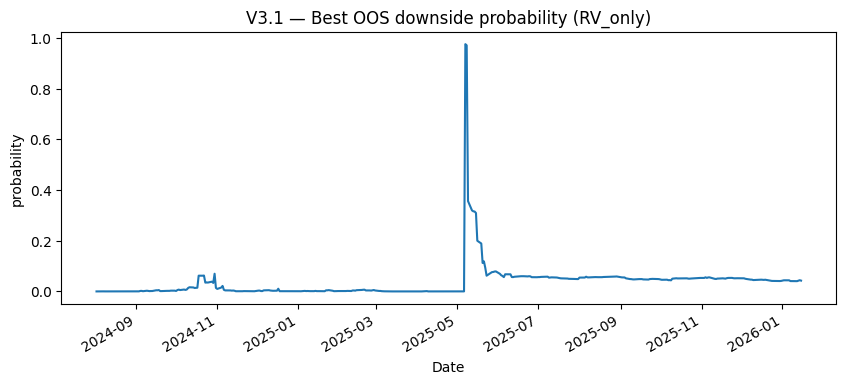

In [14]:
# ============================================================
# V3.1 — Horse race: RV vs downside semivol vs IV
# future RV, forward downside, and OOS downside-event classification
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

# -------------------------
# Fallbacks / parameters
# -------------------------
PC_CORE = globals().get("PC_CORE", "PC1")
H = int(globals().get("H_DOWNSIDE", 21))
DD_THR = float(globals().get("DD_THRESHOLD", -0.05))
MIN_TRAIN = int(globals().get("MIN_TRAIN_DAYS", 252))
REFIT = int(globals().get("REFIT_EVERY", 21))
ANN = 252

if "pc1_base" not in globals():
    pc1_base = F_wf_net[PC_CORE].dropna().astype(float).copy()
    pc1_base.name = f"{PC_CORE}_wf_net"

if "iv_X" not in globals():
    iv_X = build_iv_predictor_panel(
        iv_level=iv,
        target_index=pc1_base.index,
        z_window=252,
        z_min_obs=126,
    )

if "y_down" not in globals():
    y_down = forward_worst_return_from_returns(pc1_base, horizon=H)

# -------------------------
# Helpers
# -------------------------
def rolling_realized_vol(r: pd.Series, window: int = 21, ann: int = 252, min_obs: int | None = None) -> pd.Series:
    r = pd.Series(r).astype(float)
    if min_obs is None:
        min_obs = max(5, window // 2)
    rv = r.rolling(window, min_periods=min_obs).std(ddof=1) * np.sqrt(ann)
    return rv.rename(f"rv_{window}")

def rolling_downside_semivol(r: pd.Series, window: int = 21, ann: int = 252, mar: float = 0.0, min_obs: int | None = None) -> pd.Series:
    r = pd.Series(r).astype(float)
    if min_obs is None:
        min_obs = max(5, window // 2)
    neg = np.minimum(r - mar, 0.0)
    dsv = np.sqrt(ann * pd.Series(neg**2, index=r.index).rolling(window, min_periods=min_obs).mean())
    return dsv.rename(f"dsv_{window}")

def rolling_upside_semivol(r: pd.Series, window: int = 21, ann: int = 252, mar: float = 0.0, min_obs: int | None = None) -> pd.Series:
    r = pd.Series(r).astype(float)
    if min_obs is None:
        min_obs = max(5, window // 2)
    pos = np.maximum(r - mar, 0.0)
    usv = np.sqrt(ann * pd.Series(pos**2, index=r.index).rolling(window, min_periods=min_obs).mean())
    return usv.rename(f"usv_{window}")

def forward_realized_vol_from_returns(r: pd.Series, horizon: int = 21, ann: int = 252) -> pd.Series:
    """
    Future realized vol over the next H daily returns:
        RV_fwd,t = sqrt(ann) * std(r_{t+1}, ..., r_{t+H})
    """
    r = pd.Series(r).dropna().astype(float)
    x = r.values
    out = np.full(len(x), np.nan)
    for i in range(len(x)):
        j = min(len(x), i + horizon + 1)
        fwd = x[i + 1:j]
        if len(fwd) < max(5, horizon // 2):
            continue
        out[i] = np.std(fwd, ddof=1) * np.sqrt(ann)
    return pd.Series(out, index=r.index, name=f"rv_fwd_{horizon}")

def auc_rank(y_true: pd.Series, p_hat: pd.Series) -> float:
    """
    AUC via rank formula (no sklearn dependency).
    """
    df = pd.concat([pd.Series(y_true, name="y"), pd.Series(p_hat, name="p")], axis=1).dropna()
    if df.empty or df["y"].nunique() < 2:
        return np.nan
    y = df["y"].astype(int).values
    p = df["p"].astype(float).values
    ranks = pd.Series(p).rank(method="average").values
    n1 = int(y.sum())
    n0 = int(len(y) - n1)
    if n1 == 0 or n0 == 0:
        return np.nan
    auc = (ranks[y == 1].sum() - n1 * (n1 + 1) / 2.0) / (n1 * n0)
    return float(auc)

def brier_score(y_true: pd.Series, p_hat: pd.Series) -> float:
    df = pd.concat([pd.Series(y_true, name="y"), pd.Series(p_hat, name="p")], axis=1).dropna()
    if df.empty:
        return np.nan
    return float(np.mean((df["p"].astype(float) - df["y"].astype(float)) ** 2))

def expanding_prob_forecast(
    X: pd.DataFrame,
    event: pd.Series,
    horizon: int = 21,
    min_train: int = 252,
    refit_every: int = 21,
) -> pd.Series:
    """
    Expanding-window OOS event probability forecast:
    at date t, train only on observations whose forward target is fully known by t
    (non-leaky training end = t - horizon).
    """
    X = pd.DataFrame(X).astype(float)
    event = pd.Series(event).astype(float).reindex(X.index)

    df = pd.concat([X, event.rename("event")], axis=1).dropna()
    p_hat = pd.Series(np.nan, index=df.index, name="p_hat")

    cached_train = None
    last_fit_i = None

    for i, ts in enumerate(df.index):
        train_end_i = i - horizon
        if train_end_i < 0:
            continue

        train_df = df.iloc[: train_end_i + 1].dropna()
        if len(train_df) < min_train:
            continue

        X_train = train_df[X.columns].astype(float)
        y_train = train_df["event"].astype(int)

        if y_train.nunique() < 2:
            p_hat.loc[ts] = float(y_train.mean())
            continue

        should_refit = (
            (cached_train is None)
            or (last_fit_i is None)
            or ((i - last_fit_i) >= refit_every)
        )
        if should_refit:
            cached_train = (X_train.copy(), y_train.copy())
            last_fit_i = i

        p_hat.loc[ts] = _fit_predict_logit_prob(
            X_train=cached_train[0],
            y_train=cached_train[1],
            x_now=df.loc[ts, X.columns],
        )

    return p_hat

def ols_horse_race(df: pd.DataFrame, y_col: str, model_specs: dict, hac_lags: int = 21):
    rows = []
    tabs = {}
    for name, cols in model_specs.items():
        res, tab = hac_ols_summary(
            y=df[y_col],
            X=df[cols],
            hac_lags=hac_lags,
        )
        if res is None or tab.empty:
            continue
        rows.append(
            {
                "model": name,
                "nobs": int(res.nobs),
                "R2": float(getattr(res, "rsquared", np.nan)),
                "AdjR2": float(getattr(res, "rsquared_adj", np.nan)),
                "AIC": float(getattr(res, "aic", np.nan)),
                "BIC": float(getattr(res, "bic", np.nan)),
            }
        )
        tabs[name] = tab
    out = pd.DataFrame(rows).set_index("model") if rows else pd.DataFrame()
    if not out.empty:
        out = out.sort_values(["R2", "AdjR2"], ascending=False)
    return out, tabs

# -------------------------
# Predictors and targets
# -------------------------
rv_21 = rolling_realized_vol(pc1_base, window=H, ann=ANN)
dsv_21 = rolling_downside_semivol(pc1_base, window=H, ann=ANN)
usv_21 = rolling_upside_semivol(pc1_base, window=H, ann=ANN)  # placebo/control
rv_fwd = forward_realized_vol_from_returns(pc1_base, horizon=H, ann=ANN)

df_v31 = pd.concat(
    [
        pc1_base.rename("pc1_base"),
        y_down.rename("worst_fwd_ret"),
        rv_fwd.rename("rv_fwd"),
        rv_21.rename("rv_21"),
        dsv_21.rename("dsv_21"),
        usv_21.rename("usv_21"),
        iv_X[["log_iv", "dlog_iv", "log_iv_z"]],
    ],
    axis=1,
).dropna()

df_v31["event_dd"] = (df_v31["worst_fwd_ret"] < DD_THR).astype(int)
df_v31["iv_over_rv"] = df_v31["log_iv"] - np.log(df_v31["rv_21"].replace(0.0, np.nan))

print("V3.1 sample shape:", df_v31.shape)
print("Event rate:", round(100 * df_v31["event_dd"].mean(), 2), "%")
display(df_v31.head())

# -------------------------
# Exploratory bucket checks
# -------------------------
for feat in ["rv_21", "dsv_21", "usv_21", "log_iv"]:
    print(f"\nBucket summary by {feat}  ->  worst_fwd_ret / event_dd")
    display(bucket_summary(df_v31, feature=feat, target="worst_fwd_ret", event="event_dd", q=5))

# -------------------------
# OLS horse race
# -------------------------
model_specs = {
    "RV_only": ["rv_21"],
    "DSV_only": ["dsv_21"],
    "USV_only": ["usv_21"],
    "IV_only": ["log_iv", "dlog_iv", "log_iv_z"],
    "RV_plus_IV": ["rv_21", "log_iv", "dlog_iv", "log_iv_z"],
    "DSV_plus_IV": ["dsv_21", "log_iv", "dlog_iv", "log_iv_z"],
    "RV_DSV_plus_IV": ["rv_21", "dsv_21", "log_iv", "dlog_iv", "log_iv_z"],
}

print("\nHAC OLS horse race — future realized vol")
ols_rv_tab, ols_rv_detail = ols_horse_race(df_v31, y_col="rv_fwd", model_specs=model_specs, hac_lags=H)
display(ols_rv_tab)

print("\nHAC OLS horse race — worst forward return")
ols_dd_tab, ols_dd_detail = ols_horse_race(df_v31, y_col="worst_fwd_ret", model_specs=model_specs, hac_lags=H)
display(ols_dd_tab)

print("\nDetail: future RV, model = RV_plus_IV")
display(ols_rv_detail.get("RV_plus_IV", pd.DataFrame()))

print("\nDetail: forward downside, model = DSV_plus_IV")
display(ols_dd_detail.get("DSV_plus_IV", pd.DataFrame()))

# -------------------------
# Expanding OOS classification horse race
# -------------------------
clf_specs = {
    "RV_only": ["rv_21"],
    "DSV_only": ["dsv_21"],
    "IV_only": ["log_iv", "dlog_iv", "log_iv_z"],
    "RV_plus_IV": ["rv_21", "log_iv", "dlog_iv", "log_iv_z"],
    "DSV_plus_IV": ["dsv_21", "log_iv", "dlog_iv", "log_iv_z"],
    "ALL": ["rv_21", "dsv_21", "log_iv", "dlog_iv", "log_iv_z"],
}

clf_rows = []
p_store = {}

for name, cols in clf_specs.items():
    p_hat = expanding_prob_forecast(
        X=df_v31[cols],
        event=df_v31["event_dd"],
        horizon=H,
        min_train=MIN_TRAIN,
        refit_every=REFIT,
    )
    p_store[name] = p_hat

    yy = df_v31["event_dd"].reindex(p_hat.index)
    valid = pd.concat([yy.rename("y"), p_hat.rename("p")], axis=1).dropna()

    clf_rows.append(
        {
            "model": name,
            "oos_n": len(valid),
            "event_rate": valid["y"].mean() if len(valid) else np.nan,
            "mean_p": valid["p"].mean() if len(valid) else np.nan,
            "AUC": auc_rank(valid["y"], valid["p"]),
            "Brier": brier_score(valid["y"], valid["p"]),
        }
    )

clf_tab = pd.DataFrame(clf_rows).set_index("model").sort_values(["AUC", "Brier"], ascending=[False, True])

print("\nExpanding OOS logit horse race — downside-event classification")
display(clf_tab)

# -------------------------
# Quick visual: probabilities for the best model by AUC
# -------------------------
if not clf_tab.empty:
    best_model = clf_tab.index[0]
    p_best = p_store[best_model].rename("p_downside_best")
    plot_df = pd.concat([df_v31["event_dd"], p_best], axis=1).dropna()
    print(f"\nBest OOS classifier by AUC: {best_model}")
    display(plot_df.tail(10))

    ax = plot_df["p_downside_best"].plot(title=f"V3.1 — Best OOS downside probability ({best_model})")
    ax.set_ylabel("probability")

In [15]:
# ============================================================
# V3.2 — Statistical significance tests before any overlay
# 1) Logit: event ~ logIV_{t-1} + dIV^+_t + dIV^-_t
# 2) Future RV ~ lagged RV (Barroso-Santa Clara style) and HAR-RV
# 3) Logit + acceleration: + d2 logIV_t
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

# -------------------------
# Parameters / fallbacks
# -------------------------
PC_CORE = globals().get("PC_CORE", "PC1")
H = int(globals().get("H_DOWNSIDE", 21))          # forecast horizon
DD_THR = float(globals().get("DD_THRESHOLD", -0.05))
ANN = 252

# Core return series
if "pc1_base" not in globals():
    pc1_base = F_wf_net[PC_CORE].dropna().astype(float).copy()
    pc1_base.name = f"{PC_CORE}_wf_net"
else:
    pc1_base = pd.Series(pc1_base).dropna().astype(float).copy()

# IV panel
if "iv_X" not in globals():
    iv_X = build_iv_predictor_panel(
        iv_level=iv,
        target_index=pc1_base.index,
        z_window=252,
        z_min_obs=126,
    )

# Downside target (worst forward return) and event
if "y_down" not in globals():
    y_down = forward_worst_return_from_returns(pc1_base, horizon=H)

# -------------------------
# Helpers
# -------------------------
def rolling_realized_vol(r: pd.Series, window: int = 21, ann: int = 252, min_obs: int | None = None) -> pd.Series:
    r = pd.Series(r).astype(float)
    if min_obs is None:
        min_obs = max(5, window // 2)
    return (r.rolling(window, min_periods=min_obs).std(ddof=1) * np.sqrt(ann)).rename(f"rv_{window}")

def forward_realized_vol_from_returns(r: pd.Series, horizon: int = 21, ann: int = 252) -> pd.Series:
    r = pd.Series(r).dropna().astype(float)
    x = r.values
    out = np.full(len(x), np.nan)
    for i in range(len(x)):
        j = min(len(x), i + horizon + 1)
        fwd = x[i + 1:j]
        if len(fwd) < max(5, horizon // 2):
            continue
        out[i] = np.std(fwd, ddof=1) * np.sqrt(ann)
    return pd.Series(out, index=r.index, name=f"rv_fwd_{horizon}")

def fit_glm_binom_hac(y: pd.Series, X: pd.DataFrame, hac_lags: int = 21):
    """
    Binomial GLM with HAC covariance.
    """
    df = pd.concat([pd.Series(y, name="y"), pd.DataFrame(X)], axis=1).dropna()
    if df.empty or df["y"].nunique() < 2:
        return None, pd.DataFrame()
    yv = df["y"].astype(float)
    Xv = sm.add_constant(df.drop(columns="y").astype(float), has_constant="add")
    try:
        res = sm.GLM(yv, Xv, family=sm.families.Binomial()).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": hac_lags}
        )
    except Exception:
        # fallback without HAC if needed
        res = sm.GLM(yv, Xv, family=sm.families.Binomial()).fit()
    tab = pd.DataFrame({
        "coef": res.params,
        "zstat": res.tvalues,
        "pvalue": res.pvalues,
    })
    try:
        tab["odds_ratio"] = np.exp(res.params)
    except Exception:
        pass
    return res, tab

def fit_ols_hac(y: pd.Series, X: pd.DataFrame, hac_lags: int = 21):
    """
    OLS with HAC covariance.
    """
    df = pd.concat([pd.Series(y, name="y"), pd.DataFrame(X)], axis=1).dropna()
    if df.empty:
        return None, pd.DataFrame()
    yv = df["y"].astype(float)
    Xv = sm.add_constant(df.drop(columns="y").astype(float), has_constant="add")
    res = sm.OLS(yv, Xv).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    tab = pd.DataFrame({
        "coef": res.params,
        "tstat_HAC": res.tvalues,
        "pvalue_HAC": res.pvalues,
    })
    return res, tab

def model_summary_row(name: str, res, model_type: str):
    row = {"model": name, "type": model_type}
    if res is None:
        row.update({"nobs": np.nan, "AIC": np.nan, "BIC": np.nan, "pseudo_R2_or_R2": np.nan})
        return row
    row["nobs"] = int(getattr(res, "nobs", np.nan))
    row["AIC"] = float(getattr(res, "aic", np.nan))
    row["BIC"] = float(getattr(res, "bic", np.nan))
    if model_type == "logit":
        try:
            # McFadden pseudo-R2
            row["pseudo_R2_or_R2"] = 1.0 - res.llf / res.llnull
        except Exception:
            row["pseudo_R2_or_R2"] = np.nan
    else:
        row["pseudo_R2_or_R2"] = float(getattr(res, "rsquared", np.nan))
    return row

# -------------------------
# Build clean feature set
# -------------------------
df = pd.concat(
    [
        pc1_base.rename("pc1_base"),
        y_down.rename("worst_fwd_ret"),
        iv_X[["log_iv", "dlog_iv"]],
    ],
    axis=1,
).dropna()

df["event_dd"] = (df["worst_fwd_ret"] < DD_THR).astype(int)

# Clean logistic features:
# logIV_{t-1}, dIV^+_t, dIV^-_t
df["log_iv_lag1"] = df["log_iv"].shift(1)
df["dlog_iv_plus"] = np.maximum(df["dlog_iv"], 0.0)
df["dlog_iv_minus"] = np.minimum(df["dlog_iv"], 0.0)

# Acceleration = second difference of log IV:
# d2 logIV_t = dlog_iv_t - dlog_iv_{t-1}
df["d2log_iv"] = df["dlog_iv"] - df["dlog_iv"].shift(1)

# RV features for future-RV regressions
df["rv_21"] = rolling_realized_vol(df["pc1_base"], window=21, ann=ANN)
df["rv_5"] = rolling_realized_vol(df["pc1_base"], window=5, ann=ANN)
df["rv_fwd_H"] = forward_realized_vol_from_returns(df["pc1_base"], horizon=H, ann=ANN)

# HAR-style lags
df["rv_21_lag1"] = df["rv_21"].shift(1)
df["rv_5_lag1"] = df["rv_5"].shift(1)
df["rv_21_lag5_mean"] = df["rv_21"].shift(1).rolling(5, min_periods=5).mean()
df["rv_21_lag21_mean"] = df["rv_21"].shift(1).rolling(21, min_periods=15).mean()

df_v32 = df.dropna().copy()

print("V3.2 sample shape:", df_v32.shape)
print("Downside event rate:", round(100 * df_v32["event_dd"].mean(), 2), "%")
display(
    df_v32[
        [
            "pc1_base", "worst_fwd_ret", "event_dd",
            "log_iv_lag1", "dlog_iv_plus", "dlog_iv_minus", "d2log_iv",
            "rv_fwd_H", "rv_21_lag1", "rv_5_lag1", "rv_21_lag5_mean", "rv_21_lag21_mean"
        ]
    ].head()
)

# ============================================================
# 1) Logistic — clean Version 1
# ============================================================
X_logit_v1 = df_v32[["log_iv_lag1", "dlog_iv_plus", "dlog_iv_minus"]]
res_logit_v1, tab_logit_v1 = fit_glm_binom_hac(df_v32["event_dd"], X_logit_v1, hac_lags=H)

print("\nLogit V1 — event ~ logIV_{t-1} + dIV^+_t + dIV^-_t")
display(tab_logit_v1)

# ============================================================
# 2a) Future RV ~ lagged RV (Barroso–Santa Clara style)
# ============================================================
X_rv_bs = df_v32[["rv_21_lag1"]]
res_rv_bs, tab_rv_bs = fit_ols_hac(df_v32["rv_fwd_H"], X_rv_bs, hac_lags=H)

print("\nFuture RV regression — Barroso/Santa Clara style: RV_fwd ~ RV_{t-1}")
display(tab_rv_bs)

# ============================================================
# 2b) Future RV ~ HAR-RV style (Corsi-like)
#     using short-, weekly-, monthly-type components
# ============================================================
X_rv_har = df_v32[["rv_5_lag1", "rv_21_lag5_mean", "rv_21_lag21_mean"]]
res_rv_har, tab_rv_har = fit_ols_hac(df_v32["rv_fwd_H"], X_rv_har, hac_lags=H)

print("\nFuture RV regression — HAR style: RV_fwd ~ RV_5 + mean(RV_21, lag 1..5) + mean(RV_21, lag 1..21)")
display(tab_rv_har)

# ============================================================
# 3) Logistic — Version 1 + acceleration
# ============================================================
X_logit_acc = df_v32[["log_iv_lag1", "dlog_iv_plus", "dlog_iv_minus", "d2log_iv"]]
res_logit_acc, tab_logit_acc = fit_glm_binom_hac(df_v32["event_dd"], X_logit_acc, hac_lags=H)

print("\nLogit V1 + acceleration — event ~ logIV_{t-1} + dIV^+_t + dIV^-_t + d2logIV_t")
display(tab_logit_acc)

# ============================================================
# Compact model comparison
# ============================================================
cmp = pd.DataFrame([
    model_summary_row("Logit_V1", res_logit_v1, "logit"),
    model_summary_row("RV_BS", res_rv_bs, "ols"),
    model_summary_row("RV_HAR", res_rv_har, "ols"),
    model_summary_row("Logit_V1_plus_acc", res_logit_acc, "logit"),
]).set_index("model")

print("\nCompact model comparison")
display(cmp)

# ============================================================
# Quick interpretation helpers
# ============================================================
print("\nSignificance cheat-sheet:")
print("- For logit models, look first at p-values of log_iv_lag1, dlog_iv_plus, dlog_iv_minus, d2log_iv.")
print("- dlog_iv_plus significant with positive coef  => IV up-shocks raise downside-event probability.")
print("- dlog_iv_minus significant with negative coef => IV down-shocks reduce downside-event probability.")
print("- d2log_iv significant                         => acceleration/deceleration of IV adds information.")
print("- For future RV models, significant lagged RV / HAR terms => volatility-targeting overlay becomes a serious candidate.")

V3.2 sample shape: (736, 16)
Downside event rate: 4.48 %


,pc1_base,worst_fwd_ret,event_dd,log_iv_lag1,dlog_iv_plus,dlog_iv_minus,d2log_iv,rv_fwd_H,rv_21_lag1,rv_5_lag1,rv_21_lag5_mean,rv_21_lag21_mean
Date,,,,,,,,,,,,
2023-02-08,-0.018713,-0.055065,0,3.237109,0.038148,0.000000,0.054896,0.221772,0.282573,0.456370,0.276726,0.254107
2023-02-09,-0.008572,-0.046895,0,3.275256,0.044008,0.000000,0.005860,0.222392,0.295403,0.480013,0.286852,0.256688
2023-02-10,-0.008794,-0.038439,0,3.319264,0.000000,-0.020099,-0.064107,0.241988,0.299942,0.271515,0.291901,0.259232
2023-02-13,0.017006,-0.054518,0,3.299165,0.006256,0.000000,0.026355,0.234415,0.300410,0.239740,0.292532,0.261520
2023-02-14,0.003779,-0.058078,0,3.305420,0.000000,-0.084148,-0.090403,0.263159,0.302922,0.273201,0.296250,0.263699



Logit V1 — event ~ logIV_{t-1} + dIV^+_t + dIV^-_t


,coef,zstat,pvalue,odds_ratio
const,-11.600883,-1.993204,0.046239,0.000009
log_iv_lag1,2.858259,1.477174,0.139629,17.431146
dlog_iv_plus,-1.747853,-0.744308,0.456690,0.174147
dlog_iv_minus,8.225376,2.472870,0.013403,"3,734.525750"



Future RV regression — Barroso/Santa Clara style: RV_fwd ~ RV_{t-1}


...

,coef,zstat,pvalue,odds_ratio
const,-11.690554,-1.909796,0.056160,0.000008
log_iv_lag1,2.887412,1.418595,0.156017,17.946804
dlog_iv_plus,-2.290864,-0.674947,0.499710,0.101179
dlog_iv_minus,7.642008,1.512967,0.130288,"2,083.924617"
d2log_iv,0.538786,0.246698,0.805142,1.713925



Compact model comparison


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


,type,nobs,AIC,BIC,pseudo_R2_or_R2
model,,,,,
Logit_V1,logit,736,269.882378,"-4,570.218069",0.027939
RV_BS,ols,736,"-1,787.833531","-1,778.631071",0.091719
RV_HAR,ols,736,"-1,843.398197","-1,824.993276",0.162331
Logit_V1_plus_acc,logit,736,271.848405,"-4,563.650812",0.028065



Significance cheat-sheet:
- For logit models, look first at p-values of log_iv_lag1, dlog_iv_plus, dlog_iv_minus, d2log_iv.
- dlog_iv_plus significant with positive coef  => IV up-shocks raise downside-event probability.
- dlog_iv_minus significant with negative coef => IV down-shocks reduce downside-event probability.
- d2log_iv significant                         => acceleration/deceleration of IV adds information.
- For future RV models, significant lagged RV / HAR terms => volatility-targeting overlay becomes a serious candidate.


In [16]:
# ============================================================
# V3.3 — Realized volatility vs forward drawdown: bucket tests
# CCA-style nonparametric diagnostic
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

PC_CORE = globals().get("PC_CORE", "PC1")
H = int(globals().get("H_DOWNSIDE", 21))
DD_THR = float(globals().get("DD_THRESHOLD", -0.05))
ANN = 252

if "pc1_base" not in globals():
    pc1_base = F_wf_net[PC_CORE].dropna().astype(float).copy()
    pc1_base.name = f"{PC_CORE}_wf_net"
else:
    pc1_base = pd.Series(pc1_base).dropna().astype(float).copy()

if "y_down" not in globals():
    y_down = forward_worst_return_from_returns(pc1_base, horizon=H)

def rolling_realized_vol(r: pd.Series, window: int = 21, ann: int = 252, min_obs: int | None = None) -> pd.Series:
    r = pd.Series(r).astype(float)
    if min_obs is None:
        min_obs = max(5, window // 2)
    return (r.rolling(window, min_periods=min_obs).std(ddof=1) * np.sqrt(ann)).rename(f"rv_{window}")

def rolling_downside_semivol(r: pd.Series, window: int = 21, ann: int = 252, mar: float = 0.0, min_obs: int | None = None) -> pd.Series:
    r = pd.Series(r).astype(float)
    if min_obs is None:
        min_obs = max(5, window // 2)
    neg = np.minimum(r - mar, 0.0)
    return np.sqrt(
        ann * pd.Series(neg**2, index=r.index).rolling(window, min_periods=min_obs).mean()
    ).rename(f"dsv_{window}")

def bucket_summary_ext(df: pd.DataFrame, feature: str, target: str, event: str, q: int = 4) -> pd.DataFrame:
    tmp = df[[feature, target, event]].dropna().copy()
    tmp["bucket"] = pd.qcut(tmp[feature], q=q, duplicates="drop")
    out = tmp.groupby("bucket", observed=False).agg(
        n=(feature, "size"),
        feature_mean=(feature, "mean"),
        target_mean=(target, "mean"),
        target_median=(target, "median"),
        target_p10=(target, lambda x: x.quantile(0.10)),
        target_p25=(target, lambda x: x.quantile(0.25)),
        event_rate=(event, "mean"),
    )
    out["event_rate"] = 100 * out["event_rate"]
    return out

# ---------------------------------------
# Build sample
# ---------------------------------------
rv_21 = rolling_realized_vol(pc1_base, window=21, ann=ANN)
rv_63 = rolling_realized_vol(pc1_base, window=63, ann=ANN)
dsv_21 = rolling_downside_semivol(pc1_base, window=21, ann=ANN)
dsv_63 = rolling_downside_semivol(pc1_base, window=63, ann=ANN)

df_v33 = pd.concat(
    [
        pc1_base.rename("pc1_base"),
        y_down.rename("worst_fwd_ret"),
        rv_21.rename("rv_21"),
        rv_63.rename("rv_63"),
        dsv_21.rename("dsv_21"),
        dsv_63.rename("dsv_63"),
    ],
    axis=1,
).dropna()

df_v33["event_dd"] = (df_v33["worst_fwd_ret"] < DD_THR).astype(int)

print("V3.3 sample shape:", df_v33.shape)
print("Event rate:", round(100 * df_v33["event_dd"].mean(), 2), "%")
display(df_v33.head())

# ---------------------------------------
# Quartile bucket summaries
# ---------------------------------------
for feat in ["rv_21", "dsv_21", "rv_63", "dsv_63"]:
    print(f"\nQuartile buckets by {feat} -> forward DD / downside event")
    display(bucket_summary_ext(df_v33, feature=feat, target="worst_fwd_ret", event="event_dd", q=4))

# ---------------------------------------
# Simple monotonicity view
# ---------------------------------------
mono_rows = []
for feat in ["rv_21", "dsv_21", "rv_63", "dsv_63"]:
    tab = bucket_summary_ext(df_v33, feature=feat, target="worst_fwd_ret", event="event_dd", q=4).reset_index(drop=True)
    mono_rows.append({
        "feature": feat,
        "Q1_event_rate_%": tab.loc[0, "event_rate"],
        "Q4_event_rate_%": tab.loc[len(tab)-1, "event_rate"],
        "Q1_p10": tab.loc[0, "target_p10"],
        "Q4_p10": tab.loc[len(tab)-1, "target_p10"],
        "delta_event_rate_pp": tab.loc[len(tab)-1, "event_rate"] - tab.loc[0, "event_rate"],
        "delta_p10": tab.loc[len(tab)-1, "target_p10"] - tab.loc[0, "target_p10"],
    })

mono_tab = pd.DataFrame(mono_rows).set_index("feature")
print("\nMonotonicity check: Q4 vs Q1")
display(mono_tab.sort_values("delta_event_rate_pp", ascending=False))

V3.3 sample shape: (741, 7)
Event rate: 4.45 %


,pc1_base,worst_fwd_ret,rv_21,rv_63,dsv_21,dsv_63,event_dd
Date,,,,,,,
2023-02-15,0.005928,-0.063628,0.302071,0.272468,0.151885,0.143942,0
2023-02-16,-0.020237,-0.044288,0.307254,0.277583,0.159444,0.152633,0
2023-02-17,-0.012809,-0.031887,0.312221,0.277451,0.165195,0.154414,0
2023-02-21,-0.023185,-0.008909,0.307451,0.283167,0.183684,0.164701,0
2023-02-22,0.004522,-0.013371,0.297765,0.278989,0.183684,0.162331,0



Quartile buckets by rv_21 -> forward DD / downside event


,n,feature_mean,target_mean,target_median,target_p10,target_p25,event_rate
bucket,,,,,,,
"(0.0839, 0.157]",186,0.135582,-0.029917,-0.022898,-0.080049,-0.042807,1.612903
"(0.157, 0.185]",185,0.171490,-0.030496,-0.023288,-0.079744,-0.050500,4.324324
"(0.185, 0.207]",185,0.196116,-0.024582,-0.021382,-0.062425,-0.044774,1.081081
"(0.207, 0.591]",185,0.281073,-0.026978,-0.014006,-0.112339,-0.037522,10.810811



Quartile buckets by dsv_21 -> forward DD / downside event


...

,n,feature_mean,target_mean,target_median,target_p10,target_p25,event_rate
bucket,,,,,,,
"(0.131, 0.173]",186,0.155221,-0.031277,-0.026748,-0.076870,-0.050769,0.000000
"(0.173, 0.188]",185,0.180856,-0.036800,-0.031560,-0.087281,-0.054554,6.486486
"(0.188, 0.205]",185,0.196233,-0.020939,-0.016456,-0.059018,-0.031014,1.621622
"(0.205, 0.4]",185,0.283928,-0.022951,-0.011500,-0.077729,-0.031863,9.729730



Quartile buckets by dsv_63 -> forward DD / downside event


,n,feature_mean,target_mean,target_median,target_p10,target_p25,event_rate
bucket,,,,,,,
"(0.056, 0.109]",186,0.095746,-0.023016,-0.021793,-0.055989,-0.033880,0.000000
"(0.109, 0.128]",185,0.118962,-0.035811,-0.032152,-0.082263,-0.056388,2.702703
"(0.128, 0.145]",185,0.136688,-0.031982,-0.025854,-0.073387,-0.047495,4.324324
"(0.145, 0.268]",185,0.188230,-0.021203,-0.007298,-0.112339,-0.025000,10.810811



Monotonicity check: Q4 vs Q1


,Q1_event_rate_%,Q4_event_rate_%,Q1_p10,Q4_p10,delta_event_rate_pp,delta_p10
feature,,,,,,
dsv_63,0.000000,10.810811,-0.055989,-0.112339,10.810811,-0.056350
rv_63,0.000000,9.729730,-0.076870,-0.077729,9.729730,-0.000858
rv_21,1.612903,10.810811,-0.080049,-0.112339,9.197908,-0.032289
dsv_21,5.376344,11.351351,-0.093562,-0.113199,5.975007,-0.019637


In [17]:
# ============================================================
# V3.4 — Proper development / OOS design for the overlay model
# Development sample: up to TRAIN_END_DEFAULT
# OOS sample: from TEST_START_DEFAULT onward
#
# IMPORTANT:
# with START="2015-01-01" and WF_TRAIN_YEARS=5, the earliest
# tradable walk-forward series starts around 2020, not 2015.
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

# -------------------------
# Core parameters
# -------------------------
PC_CORE = globals().get("PC_CORE", "PC1")
H = int(globals().get("H_DOWNSIDE", 21))
DD_THR = float(globals().get("DD_THRESHOLD", -0.05))
ANN = 252

DEV_END = pd.Timestamp(globals().get("TRAIN_END_DEFAULT", "2022-12-31"))
OOS_START = pd.Timestamp(globals().get("TEST_START_DEFAULT", "2023-01-01"))

# Earliest feasible walk-forward start given current raw data span and warm-up
WF_FIRST_TRADABLE = (pd.Timestamp(globals().get("START", "2015-01-01")) + pd.DateOffset(years=WF_TRAIN_YEARS)).normalize()

print("Earliest feasible walk-forward start with current settings:", WF_FIRST_TRADABLE.date())
print("Development end:", DEV_END.date(), "| OOS start:", OOS_START.date())

# -------------------------
# Helpers
# -------------------------
def rolling_realized_vol(r: pd.Series, window: int = 21, ann: int = 252, min_obs: int | None = None) -> pd.Series:
    r = pd.Series(r).astype(float)
    if min_obs is None:
        min_obs = max(5, window // 2)
    return (r.rolling(window, min_periods=min_obs).std(ddof=1) * np.sqrt(ann)).rename(f"rv_{window}")

def forward_realized_vol_from_returns(r: pd.Series, horizon: int = 21, ann: int = 252) -> pd.Series:
    r = pd.Series(r).dropna().astype(float)
    x = r.values
    out = np.full(len(x), np.nan)
    for i in range(len(x)):
        j = min(len(x), i + horizon + 1)
        fwd = x[i + 1:j]
        if len(fwd) < max(5, horizon // 2):
            continue
        out[i] = np.std(fwd, ddof=1) * np.sqrt(ann)
    return pd.Series(out, index=r.index, name=f"rv_fwd_{horizon}")

def fit_glm_binom_hac(y: pd.Series, X: pd.DataFrame, hac_lags: int = 21):
    df = pd.concat([pd.Series(y, name="y"), pd.DataFrame(X)], axis=1).dropna()
    if df.empty or df["y"].nunique() < 2:
        return None, pd.DataFrame()

    yv = df["y"].astype(float)
    Xv = sm.add_constant(df.drop(columns="y").astype(float), has_constant="add")

    try:
        res = sm.GLM(yv, Xv, family=sm.families.Binomial()).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": hac_lags}
        )
    except Exception:
        res = sm.GLM(yv, Xv, family=sm.families.Binomial()).fit()

    tab = pd.DataFrame({
        "coef": res.params,
        "zstat": res.tvalues,
        "pvalue": res.pvalues,
        "odds_ratio": np.exp(res.params),
    })
    return res, tab

def fit_ols_hac(y: pd.Series, X: pd.DataFrame, hac_lags: int = 21):
    df = pd.concat([pd.Series(y, name="y"), pd.DataFrame(X)], axis=1).dropna()
    if df.empty:
        return None, pd.DataFrame()

    yv = df["y"].astype(float)
    Xv = sm.add_constant(df.drop(columns="y").astype(float), has_constant="add")
    res = sm.OLS(yv, Xv).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

    tab = pd.DataFrame({
        "coef": res.params,
        "tstat_HAC": res.tvalues,
        "pvalue_HAC": res.pvalues,
    })
    return res, tab

def model_summary_row(name: str, res, model_type: str):
    row = {"model": name, "type": model_type}
    if res is None:
        row.update({"nobs": np.nan, "AIC": np.nan, "BIC": np.nan, "pseudo_R2_or_R2": np.nan})
        return row
    row["nobs"] = int(getattr(res, "nobs", np.nan))
    row["AIC"] = float(getattr(res, "aic", np.nan))
    row["BIC"] = float(getattr(res, "bic", np.nan))
    if model_type == "logit":
        try:
            row["pseudo_R2_or_R2"] = 1.0 - res.llf / res.llnull
        except Exception:
            row["pseudo_R2_or_R2"] = np.nan
    else:
        row["pseudo_R2_or_R2"] = float(getattr(res, "rsquared", np.nan))
    return row

def auc_rank(y_true: pd.Series, p_hat: pd.Series) -> float:
    df = pd.concat([pd.Series(y_true, name="y"), pd.Series(p_hat, name="p")], axis=1).dropna()
    if df.empty or df["y"].nunique() < 2:
        return np.nan
    y = df["y"].astype(int).values
    p = df["p"].astype(float).values
    ranks = pd.Series(p).rank(method="average").values
    n1 = int(y.sum())
    n0 = int(len(y) - n1)
    if n1 == 0 or n0 == 0:
        return np.nan
    return float((ranks[y == 1].sum() - n1 * (n1 + 1) / 2.0) / (n1 * n0))

def brier_score(y_true: pd.Series, p_hat: pd.Series) -> float:
    df = pd.concat([pd.Series(y_true, name="y"), pd.Series(p_hat, name="p")], axis=1).dropna()
    if df.empty:
        return np.nan
    return float(np.mean((df["p"].astype(float) - df["y"].astype(float)) ** 2))

# -------------------------
# 1) Build a longer walk-forward tradable series
# -------------------------
# This is the series on which the overlay model should be developed/tested.
F_wf_long, F_wf_net_long, W_hist_long = walk_forward_pca(
    R=R,
    start_test=str(WF_FIRST_TRADABLE.date()),
    train_years=WF_TRAIN_YEARS,
    step_months=WF_STEP_MONTHS,
    k=WF_K_CHOICE,
    gross_norm=GROSS_NORM,
    tc_bps=None,
    asset_costs=asset_costs,
    charge_initial_rebalance=False,
)

pc1_long = F_wf_net_long[PC_CORE].dropna().astype(float).copy()
pc1_long.name = f"{PC_CORE}_wf_net_long"

print("Long walk-forward net series:")
print(pc1_long.index.min().date(), "->", pc1_long.index.max().date(), "| n =", len(pc1_long))

# -------------------------
# 2) Build full panel on the long tradable series
# -------------------------
iv_panel_long = build_iv_predictor_panel(
    iv_level=iv,
    target_index=pc1_long.index,
    z_window=252,
    z_min_obs=126,
)

y_down_long = forward_worst_return_from_returns(pc1_long, horizon=H)

panel = pd.concat(
    [
        pc1_long.rename("pc1_base"),
        y_down_long.rename("worst_fwd_ret"),
        iv_panel_long[["log_iv", "dlog_iv"]],
    ],
    axis=1,
).dropna()

panel["event_dd"] = (panel["worst_fwd_ret"] < DD_THR).astype(int)

# Logistic V1 features
panel["log_iv_lag1"] = panel["log_iv"].shift(1)
panel["dlog_iv_plus"] = np.maximum(panel["dlog_iv"], 0.0)
panel["dlog_iv_minus"] = np.minimum(panel["dlog_iv"], 0.0)

# Acceleration
panel["d2log_iv"] = panel["dlog_iv"] - panel["dlog_iv"].shift(1)

# RV features
panel["rv_21"] = rolling_realized_vol(panel["pc1_base"], window=21, ann=ANN)
panel["rv_5"] = rolling_realized_vol(panel["pc1_base"], window=5, ann=ANN)
panel["rv_fwd_H"] = forward_realized_vol_from_returns(panel["pc1_base"], horizon=H, ann=ANN)

# HAR-style lagged components
panel["rv_21_lag1"] = panel["rv_21"].shift(1)
panel["rv_5_lag1"] = panel["rv_5"].shift(1)
panel["rv_21_lag5_mean"] = panel["rv_21"].shift(1).rolling(5, min_periods=5).mean()
panel["rv_21_lag21_mean"] = panel["rv_21"].shift(1).rolling(21, min_periods=15).mean()

panel = panel.dropna().copy()

# -------------------------
# 3) Proper split: development vs OOS
# -------------------------
dev = panel.loc[:DEV_END].copy()
oos = panel.loc[OOS_START:].copy()

print("\nPanel ranges after lag/rolling/forward construction:")
print("Full panel :", panel.index.min().date(), "->", panel.index.max().date(), "| n =", len(panel))
print("DEV sample :", dev.index.min().date() if len(dev) else None, "->", dev.index.max().date() if len(dev) else None, "| n =", len(dev))
print("OOS sample :", oos.index.min().date() if len(oos) else None, "->", oos.index.max().date() if len(oos) else None, "| n =", len(oos))
print("DEV downside event rate:", round(100 * dev["event_dd"].mean(), 2) if len(dev) else np.nan, "%")
print("OOS downside event rate:", round(100 * oos["event_dd"].mean(), 2) if len(oos) else np.nan, "%")

display(dev.head())

# -------------------------
# 4) DEVELOPMENT-SAMPLE significance tests
# -------------------------
# 4a) Logit V1
X_logit_v1_dev = dev[["log_iv_lag1", "dlog_iv_plus", "dlog_iv_minus"]]
res_logit_v1_dev, tab_logit_v1_dev = fit_glm_binom_hac(dev["event_dd"], X_logit_v1_dev, hac_lags=H)

print("\nDEV — Logit V1: event ~ logIV_{t-1} + dIV^+_t + dIV^-_t")
display(tab_logit_v1_dev)

# 4b) Logit V1 + acceleration
X_logit_acc_dev = dev[["log_iv_lag1", "dlog_iv_plus", "dlog_iv_minus", "d2log_iv"]]
res_logit_acc_dev, tab_logit_acc_dev = fit_glm_binom_hac(dev["event_dd"], X_logit_acc_dev, hac_lags=H)

print("\nDEV — Logit V1 + acceleration")
display(tab_logit_acc_dev)

# 4c) Future RV ~ lagged RV (Barroso–Santa Clara style)
X_rv_bs_dev = dev[["rv_21_lag1"]]
res_rv_bs_dev, tab_rv_bs_dev = fit_ols_hac(dev["rv_fwd_H"], X_rv_bs_dev, hac_lags=H)

print("\nDEV — Future RV regression: RV_fwd ~ RV_{t-1}")
display(tab_rv_bs_dev)

# 4d) Future RV ~ HAR-RV
X_rv_har_dev = dev[["rv_5_lag1", "rv_21_lag5_mean", "rv_21_lag21_mean"]]
res_rv_har_dev, tab_rv_har_dev = fit_ols_hac(dev["rv_fwd_H"], X_rv_har_dev, hac_lags=H)

print("\nDEV — Future RV regression: HAR style")
display(tab_rv_har_dev)

# -------------------------
# 5) Compact comparison on DEVELOPMENT sample
# -------------------------
cmp_dev = pd.DataFrame([
    model_summary_row("DEV_Logit_V1", res_logit_v1_dev, "logit"),
    model_summary_row("DEV_Logit_V1_plus_acc", res_logit_acc_dev, "logit"),
    model_summary_row("DEV_RV_BS", res_rv_bs_dev, "ols"),
    model_summary_row("DEV_RV_HAR", res_rv_har_dev, "ols"),
]).set_index("model")

print("\nDevelopment-sample model comparison")
display(cmp_dev)

# -------------------------
# 6) Quick frozen-coefficient OOS diagnostic (no overlay yet)
# -------------------------
oos_diag_rows = []

if len(oos) > 0 and res_logit_v1_dev is not None:
    X_oos_v1 = sm.add_constant(oos[["log_iv_lag1", "dlog_iv_plus", "dlog_iv_minus"]], has_constant="add")
    p_oos_v1 = pd.Series(res_logit_v1_dev.predict(X_oos_v1), index=oos.index, name="p_oos_v1")
    oos_diag_rows.append({
        "model": "Frozen_Logit_V1",
        "oos_n": len(p_oos_v1.dropna()),
        "AUC": auc_rank(oos["event_dd"], p_oos_v1),
        "Brier": brier_score(oos["event_dd"], p_oos_v1),
        "mean_p": float(p_oos_v1.mean()),
        "event_rate": float(oos["event_dd"].mean()),
    })

if len(oos) > 0 and res_logit_acc_dev is not None:
    X_oos_acc = sm.add_constant(oos[["log_iv_lag1", "dlog_iv_plus", "dlog_iv_minus", "d2log_iv"]], has_constant="add")
    p_oos_acc = pd.Series(res_logit_acc_dev.predict(X_oos_acc), index=oos.index, name="p_oos_acc")
    oos_diag_rows.append({
        "model": "Frozen_Logit_V1_plus_acc",
        "oos_n": len(p_oos_acc.dropna()),
        "AUC": auc_rank(oos["event_dd"], p_oos_acc),
        "Brier": brier_score(oos["event_dd"], p_oos_acc),
        "mean_p": float(p_oos_acc.mean()),
        "event_rate": float(oos["event_dd"].mean()),
    })

if oos_diag_rows:
    oos_diag = pd.DataFrame(oos_diag_rows).set_index("model")
    print("\nQuick frozen-coefficient OOS diagnostic (no overlay yet)")
    display(oos_diag)

print("\nWhat to look at now:")
print("1) Development sample first: significance and signs.")
print("2) Only if a model is sensible in DEV do we care about frozen OOS diagnostics.")
print("3) If RV/HAR is the stronger block again, the next overlay to build should be a volatility overlay, not the IV-logit one.")

Earliest feasible walk-forward start with current settings: 2020-01-01
Development end: 2022-12-31 | OOS start: 2023-01-01
Long walk-forward net series:
2020-01-02 -> 2026-01-30 | n = 1528

Panel ranges after lag/rolling/forward construction:
Full panel : 2020-02-07 -> 2026-01-14 | n = 1492
DEV sample : 2020-02-07 -> 2022-12-30 | n = 731
OOS sample : 2023-01-03 -> 2026-01-14 | n = 761
DEV downside event rate: 16.01 %
OOS downside event rate: 4.34 %


,pc1_base,worst_fwd_ret,log_iv,dlog_iv,event_dd,log_iv_lag1,dlog_iv_plus,dlog_iv_minus,d2log_iv,rv_21,rv_5,rv_fwd_H,rv_21_lag1,rv_5_lag1,rv_21_lag5_mean,rv_21_lag21_mean
Date,,,,,,,,,,,,,,,,
2020-02-07,-0.002102,-0.165601,2.966303,0.053409,1,2.912894,0.053409,0.000000,0.059367,0.153360,0.145140,0.501402,0.153107,0.187455,0.150592,0.134821
2020-02-10,0.015139,-0.178045,2.960623,-0.005680,1,2.966303,0.000000,-0.005680,-0.059090,0.157082,0.146982,0.520192,0.153360,0.145140,0.152291,0.135980
2020-02-11,-0.003090,-0.252016,2.978586,0.017963,1,2.960623,0.017963,0.000000,0.023643,0.158215,0.122455,0.604933,0.157082,0.146982,0.154194,0.137221
2020-02-12,0.012366,-0.261153,2.892592,-0.085995,1,2.978586,0.000000,-0.085995,-0.103958,0.158120,0.133109,0.740020,0.158215,0.122455,0.154859,0.138387
2020-02-13,-0.006882,-0.275103,2.915606,0.023015,1,2.892592,0.023015,0.000000,0.109009,0.157776,0.157910,0.840558,0.158120,0.133109,0.155977,0.139426



DEV — Logit V1: event ~ logIV_{t-1} + dIV^+_t + dIV^-_t


,coef,zstat,pvalue,odds_ratio
const,-0.573204,-0.173460,0.862290,0.563716
log_iv_lag1,-0.394736,-0.406624,0.684284,0.673858
dlog_iv_plus,3.972214,1.224624,0.220717,53.101989
dlog_iv_minus,-5.589165,-1.262264,0.206854,0.003738



DEV — Logit V1 + acceleration


...

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


,type,nobs,AIC,BIC,pseudo_R2_or_R2
model,,,,,
DEV_Logit_V1,logit,731,645.719902,"-4,156.418683",0.008104
DEV_Logit_V1_plus_acc,logit,731,646.144154,"-4,151.400018",0.010555
DEV_RV_BS,ols,731,-791.476833,-782.288006,0.173928
DEV_RV_HAR,ols,731,-840.550640,-822.172986,0.231779



Quick frozen-coefficient OOS diagnostic (no overlay yet)


,oos_n,AUC,Brier,mean_p,event_rate
model,,,,,
Frozen_Logit_V1,761,0.458292,0.059114,0.171984,0.043364
Frozen_Logit_V1_plus_acc,761,0.480561,0.060120,0.174769,0.043364



What to look at now:
1) Development sample first: significance and signs.
2) Only if a model is sensible in DEV do we care about frozen OOS diagnostics.
3) If RV/HAR is the stronger block again, the next overlay to build should be a volatility overlay, not the IV-logit one.


## 7) Current preferred overlay — slow volatility-distribution control

This is the **current main overlay path**.

The workflow is:

1. estimate the conditional mean of **forward realized volatility** with a HAR-RV model;
2. add uncertainty through **residual bootstrapping** to obtain a predictive distribution;
3. convert that distribution into a **volatility-state score** (probability that forward volatility exceeds a threshold);
4. map the score into a **slow, percentile-based exposure rule** with hysteresis;
5. evaluate the overlay **net of spread-based costs**.

The goal is not to maximize raw CAGR, but to improve the **quality of the return path** of the investable PC1 baseline.


HAR fit on development sample
n_dev: 731


,coef,tstat,pvalue
const,0.182630,15.910649,0.000000
rv_5_lag1,0.282942,6.970624,0.000000
rv_21_lag5_mean,0.317751,3.232074,0.001284
rv_21_lag21_mean,-0.220637,-2.577040,0.010161



Chosen volatility threshold tau = 0.371865 (dev p80)

OOS predictive distribution diagnostics


,value
oos_n,761.000000
tau,0.371865
event_rate_%,3.153745
mean_pred_p_%,10.265519
AUC,0.944708
Brier,0.035768



Probability calibration by buckets


,n,mean_p,realized_rate
bucket,,,
"(0.037399999999999996, 0.0614]",154,5.387662,0.000000
"(0.0614, 0.0754]",151,6.870199,0.000000
"(0.0754, 0.0866]",153,8.036993,0.000000
"(0.0866, 0.117]",151,9.880132,0.662252
"(0.117, 0.995]",152,21.206579,15.131579



Tail of OOS predictive table


,realized_rv_fwd,rv_pred_mean,rv_pred_std,rv_q90,p_rv_exceed,event_rv_exceed
Date,,,,,,
2025-12-31,0.205363,0.196331,0.131241,0.303887,0.048800,0
2026-01-02,0.201838,0.208364,0.136214,0.312944,0.052000,0
2026-01-05,0.205930,0.230326,0.138077,0.335153,0.062800,0
2026-01-06,0.206789,0.232153,0.136656,0.339397,0.067200,0
2026-01-07,0.211927,0.241671,0.132637,0.345831,0.075200,0
2026-01-08,0.219922,0.242938,0.131227,0.349349,0.072200,0
2026-01-09,0.228059,0.242311,0.128981,0.344550,0.068600,0
2026-01-12,0.236777,0.214082,0.130436,0.319376,0.046800,0
2026-01-13,0.239298,0.216214,0.133208,0.320989,0.053400,0



Saved object: har_boot_oos


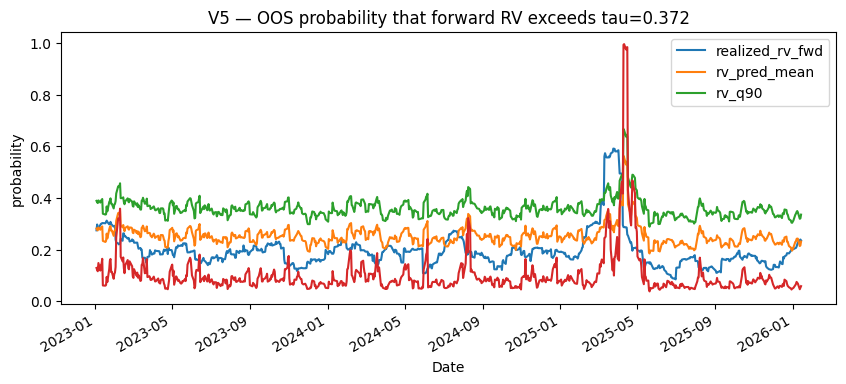

In [18]:
# ============================================================
# V5 — HAR-RV + residual bootstrap predictive distribution
# Goal: estimate P( RV_fwd_H > tau | information at t )
# using HAR mean dynamics + bootstrapped residual uncertainty
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

# ------------------------------------------------------------
# Preconditions:
# expects dev / oos from V3.4 already available
# with columns:
#   rv_fwd_H, rv_5_lag1, rv_21_lag5_mean, rv_21_lag21_mean
# ------------------------------------------------------------
assert "dev" in globals() and "oos" in globals(), "Run V3.4 first so that dev and oos exist."

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
BOOT_B = 5000                 # number of bootstrap draws
TAU_MODE = "dev_percentile"   # "dev_percentile" or "absolute"
TAU_PERCENTILE = 0.80         # e.g. 0.80, 0.85, 0.90
TAU_ABS = 0.30                # used only if TAU_MODE == "absolute"

HAR_COLS = ["rv_5_lag1", "rv_21_lag5_mean", "rv_21_lag21_mean"]
Y_COL = "rv_fwd_H"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def auc_rank(y_true: pd.Series, p_hat: pd.Series) -> float:
    df = pd.concat([pd.Series(y_true, name="y"), pd.Series(p_hat, name="p")], axis=1).dropna()
    if df.empty or df["y"].nunique() < 2:
        return np.nan
    y = df["y"].astype(int).values
    p = df["p"].astype(float).values
    ranks = pd.Series(p).rank(method="average").values
    n1 = int(y.sum())
    n0 = int(len(y) - n1)
    if n1 == 0 or n0 == 0:
        return np.nan
    auc = (ranks[y == 1].sum() - n1 * (n1 + 1) / 2.0) / (n1 * n0)
    return float(auc)

def brier_score(y_true: pd.Series, p_hat: pd.Series) -> float:
    df = pd.concat([pd.Series(y_true, name="y"), pd.Series(p_hat, name="p")], axis=1).dropna()
    if df.empty:
        return np.nan
    return float(np.mean((df["p"].astype(float) - df["y"].astype(float)) ** 2))

def bucket_prob_calibration(y_true: pd.Series, p_hat: pd.Series, q: int = 5) -> pd.DataFrame:
    tmp = pd.concat([pd.Series(y_true, name="y"), pd.Series(p_hat, name="p")], axis=1).dropna().copy()
    if tmp.empty:
        return pd.DataFrame()
    tmp["bucket"] = pd.qcut(tmp["p"], q=q, duplicates="drop")
    out = tmp.groupby("bucket", observed=False).agg(
        n=("y", "size"),
        mean_p=("p", "mean"),
        realized_rate=("y", "mean"),
    )
    out["realized_rate"] *= 100
    out["mean_p"] *= 100
    return out

# ------------------------------------------------------------
# 1) Fit HAR on development sample
# ------------------------------------------------------------
har_dev = dev[[Y_COL] + HAR_COLS].dropna().copy()
X_dev = sm.add_constant(har_dev[HAR_COLS], has_constant="add")
y_dev = har_dev[Y_COL].astype(float)

har_res = sm.OLS(y_dev, X_dev).fit()
har_resid = (y_dev - har_res.fittedvalues).dropna()

print("HAR fit on development sample")
print("n_dev:", len(har_dev))
display(pd.DataFrame({
    "coef": har_res.params,
    "tstat": har_res.tvalues,
    "pvalue": har_res.pvalues,
}))

# ------------------------------------------------------------
# 2) Choose threshold tau
# ------------------------------------------------------------
if TAU_MODE == "dev_percentile":
    tau = float(dev[Y_COL].dropna().quantile(TAU_PERCENTILE))
    tau_label = f"dev p{int(TAU_PERCENTILE*100)}"
else:
    tau = float(TAU_ABS)
    tau_label = f"absolute {TAU_ABS:.4f}"

print(f"\nChosen volatility threshold tau = {tau:.6f} ({tau_label})")

# ------------------------------------------------------------
# 3) OOS predictive distribution via residual bootstrap
#    Frozen-coefficient version first (clean baseline)
# ------------------------------------------------------------
har_oos = oos[[Y_COL] + HAR_COLS].dropna().copy()
X_oos = sm.add_constant(har_oos[HAR_COLS], has_constant="add")
mu_oos = pd.Series(har_res.predict(X_oos), index=har_oos.index, name="mu_hat")

# bootstrap residual draws
resid_pool = har_resid.values.astype(float)
boot_draws = np.random.choice(resid_pool, size=(len(mu_oos), BOOT_B), replace=True)

# predictive draws: mean + resampled residual
pred_draws = mu_oos.values.reshape(-1, 1) + boot_draws

# optional clipping to nonnegative values
pred_draws = np.clip(pred_draws, 1e-8, None)

# predictive summaries
p_exceed = pd.Series((pred_draws > tau).mean(axis=1), index=mu_oos.index, name="p_rv_exceed")
q90 = pd.Series(np.quantile(pred_draws, 0.90, axis=1), index=mu_oos.index, name="rv_q90")
pred_mean = pd.Series(pred_draws.mean(axis=1), index=mu_oos.index, name="rv_pred_mean")
pred_std = pd.Series(pred_draws.std(axis=1, ddof=1), index=mu_oos.index, name="rv_pred_std")

# realized event
event_oos = (har_oos[Y_COL] > tau).astype(int).rename("event_rv_exceed")

# ------------------------------------------------------------
# 4) Diagnostics
# ------------------------------------------------------------
diag = pd.DataFrame({
    "realized_rv_fwd": har_oos[Y_COL],
    "rv_pred_mean": pred_mean,
    "rv_pred_std": pred_std,
    "rv_q90": q90,
    "p_rv_exceed": p_exceed,
    "event_rv_exceed": event_oos,
})

print("\nOOS predictive distribution diagnostics")
summary_diag = pd.DataFrame([{
    "oos_n": len(diag),
    "tau": tau,
    "event_rate_%": 100 * diag["event_rv_exceed"].mean(),
    "mean_pred_p_%": 100 * diag["p_rv_exceed"].mean(),
    "AUC": auc_rank(diag["event_rv_exceed"], diag["p_rv_exceed"]),
    "Brier": brier_score(diag["event_rv_exceed"], diag["p_rv_exceed"]),
}]).T
summary_diag.columns = ["value"]
display(summary_diag)

print("\nProbability calibration by buckets")
display(bucket_prob_calibration(diag["event_rv_exceed"], diag["p_rv_exceed"], q=5))

print("\nTail of OOS predictive table")
display(diag.tail(10))

# ------------------------------------------------------------
# 5) Simple plots
# ------------------------------------------------------------
ax = diag[["realized_rv_fwd", "rv_pred_mean", "rv_q90"]].plot(
    title=f"V5 — OOS HAR predictive distribution | tau={tau:.3f}"
)
ax.set_ylabel("forward realized volatility")

ax2 = diag["p_rv_exceed"].plot(
    title=f"V5 — OOS probability that forward RV exceeds tau={tau:.3f}"
)
ax2.set_ylabel("probability")

# ------------------------------------------------------------
# 6) Save useful objects for next overlay step
# ------------------------------------------------------------
har_boot_oos = diag.copy()
har_boot_oos["tau"] = tau
har_boot_oos["tau_mode"] = tau_label

print("\nSaved object: har_boot_oos")

In [19]:
# ============================================================
# V5.1 — Slow overlay from HAR-bootstrap volatility score
# Weekly rebalance + hysteresis + mild de-risking
# Uses har_boot_oos from V5 and oos from V3.4
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

assert "har_boot_oos" in globals(), "Run V5 first so that har_boot_oos exists."
assert "oos" in globals(), "Run V3.4 first so that oos exists."

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
BASE_COL = "pc1_base"
SCORE_COL = "p_rv_exceed"

# exposure states
EXP_NORMAL = 1.00
EXP_DEF = 0.75
EXP_EXT = 0.50

# hysteresis on expanding percentiles of the score
ENTER_DEF_Q = 0.90
EXIT_DEF_Q  = 0.75
ENTER_EXT_Q = 0.98
EXIT_EXT_Q  = 0.90

MIN_HIST_WEEKS = 26          # before this, stay fully invested
OVERLAY_COST_BPS = 0.0       # can raise later if you want

# ------------------------------------------------------------
# Helper: performance table
# ------------------------------------------------------------
def perf_table(return_dict: dict[str, pd.Series], ann: int = 252) -> pd.DataFrame:
    rows = []
    for name, r in return_dict.items():
        r = pd.Series(r).dropna().astype(float)
        if r.empty:
            continue

        wealth = (1.0 + r).cumprod()
        n = len(r)
        years = n / ann

        cagr = wealth.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
        vol = r.std(ddof=1) * np.sqrt(ann)
        mu = r.mean() * ann
        sharpe = mu / vol if vol > 0 else np.nan

        downside = r[r < 0]
        dvol = downside.std(ddof=1) * np.sqrt(ann) if len(downside) > 1 else np.nan
        sortino = mu / dvol if pd.notna(dvol) and dvol > 0 else np.nan

        peak = wealth.cummax()
        dd = wealth / peak - 1.0
        max_dd = dd.min()
        calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

        ulcer = np.sqrt(np.mean((100 * dd) ** 2)) / 100
        martin = cagr / ulcer if ulcer > 0 else np.nan

        rows.append({
            "n": n,
            "CAGR": cagr,
            "AnnRet": mu,
            "AnnVol": vol,
            "Sharpe": sharpe,
            "Sortino": sortino,
            "MaxDD": max_dd,
            "Calmar": calmar,
            "Ulcer": ulcer,
            "Martin": martin,
        })

    return pd.DataFrame(rows, index=list(return_dict.keys()))

# ------------------------------------------------------------
# 1) Build daily base series and score series
# ------------------------------------------------------------
base_r = oos[BASE_COL].dropna().astype(float).copy()
score_daily = har_boot_oos[SCORE_COL].dropna().astype(float).copy()

# align on common daily index
common_idx = base_r.index.intersection(score_daily.index)
base_r = base_r.loc[common_idx]
score_daily = score_daily.loc[common_idx]

# weekly rebalance score = last available score each week
score_weekly = score_daily.resample("W-FRI").last().dropna()

# ------------------------------------------------------------
# 2) State machine with expanding percentile thresholds
# ------------------------------------------------------------
state_rows = []
state = "normal"

for i, dt in enumerate(score_weekly.index):
    p_now = float(score_weekly.loc[dt])

    hist = score_weekly.iloc[:i]
    if len(hist) < MIN_HIST_WEEKS:
        q_def_enter = q_def_exit = q_ext_enter = q_ext_exit = np.nan
        state = "normal"
        exposure = EXP_NORMAL
    else:
        q_def_enter = float(hist.quantile(ENTER_DEF_Q))
        q_def_exit  = float(hist.quantile(EXIT_DEF_Q))
        q_ext_enter = float(hist.quantile(ENTER_EXT_Q))
        q_ext_exit  = float(hist.quantile(EXIT_EXT_Q))

        if state == "normal":
            if p_now >= q_ext_enter:
                state = "extreme"
            elif p_now >= q_def_enter:
                state = "defensive"

        elif state == "defensive":
            if p_now >= q_ext_enter:
                state = "extreme"
            elif p_now <= q_def_exit:
                state = "normal"

        elif state == "extreme":
            if p_now <= q_ext_exit:
                # de-escalate with hysteresis
                if p_now <= q_def_exit:
                    state = "normal"
                else:
                    state = "defensive"

        exposure = {
            "normal": EXP_NORMAL,
            "defensive": EXP_DEF,
            "extreme": EXP_EXT,
        }[state]

    state_rows.append({
        "Date": dt,
        "p_score": p_now,
        "q_def_enter": q_def_enter,
        "q_def_exit": q_def_exit,
        "q_ext_enter": q_ext_enter,
        "q_ext_exit": q_ext_exit,
        "state": state,
        "exposure_signal": exposure,
    })

weekly_overlay = pd.DataFrame(state_rows).set_index("Date")

print("Weekly overlay state table")
display(weekly_overlay.tail(15))

# ------------------------------------------------------------
# 3) Push weekly signal to daily frequency
# ------------------------------------------------------------
exposure_signal_daily = weekly_overlay["exposure_signal"].reindex(base_r.index, method="ffill").fillna(EXP_NORMAL)

# apply from next trading day to avoid same-day look-ahead
exposure_applied = exposure_signal_daily.shift(1).fillna(EXP_NORMAL).rename("exposure_applied")

# turnover + optional cost
overlay_turnover = exposure_applied.diff().abs().fillna(0.0).rename("overlay_turnover")
overlay_cost = (OVERLAY_COST_BPS / 10000.0) * overlay_turnover
overlay_r = (exposure_applied * base_r - overlay_cost).rename("overlay_r")

# ------------------------------------------------------------
# 4) Collect diagnostic panel
# ------------------------------------------------------------
overlay_panel = pd.concat(
    [
        base_r.rename("base_r"),
        score_daily.rename("p_score_daily"),
        exposure_signal_daily.rename("exposure_signal_daily"),
        exposure_applied,
        overlay_turnover,
        overlay_cost.rename("overlay_cost"),
        overlay_r,
    ],
    axis=1,
)

print("\nOverlay daily panel tail")
display(overlay_panel.tail(15))

# ------------------------------------------------------------
# 5) Compare performance
# ------------------------------------------------------------
perf = perf_table({
    "PC1_base_OOS": base_r,
    "PC1_slow_overlay": overlay_r,
})

print("\nPerformance comparison")
display(perf)

# ------------------------------------------------------------
# 6) Event concentration check
#    Do high-score / de-risk states line up with realized RV exceedance events?
# ------------------------------------------------------------
if "event_rv_exceed" in har_boot_oos.columns:
    event_daily = har_boot_oos["event_rv_exceed"].reindex(base_r.index)
    event_check = pd.concat(
        [
            event_daily.rename("event_rv_exceed"),
            score_daily.rename("p_score"),
            exposure_signal_daily.rename("exposure_signal"),
        ],
        axis=1,
    ).dropna()

    state_summary = event_check.groupby("exposure_signal", observed=False).agg(
        n=("event_rv_exceed", "size"),
        mean_p=("p_score", "mean"),
        event_rate=("event_rv_exceed", "mean"),
    )
    state_summary["event_rate"] *= 100

    print("\nEvent concentration by exposure state")
    display(state_summary)

# ------------------------------------------------------------
# 7) Save useful objects
# ------------------------------------------------------------
slow_overlay_oos = overlay_panel.copy()
slow_overlay_weekly = weekly_overlay.copy()

print("\nSaved objects: slow_overlay_oos, slow_overlay_weekly")

Weekly overlay state table


,p_score,q_def_enter,q_def_exit,q_ext_enter,q_ext_exit,state,exposure_signal
Date,,,,,,,
2025-10-10,0.053600,0.154020,0.105600,0.376424,0.154020,normal,1.000000
2025-10-17,0.132000,0.153760,0.105600,0.375192,0.153760,normal,1.000000
2025-10-24,0.070800,0.153500,0.105600,0.373960,0.153500,normal,1.000000
2025-10-31,0.085000,0.153240,0.105600,0.372728,0.153240,normal,1.000000
2025-11-07,0.091400,0.152980,0.105600,0.371496,0.152980,normal,1.000000
2025-11-14,0.088400,0.152720,0.105600,0.370264,0.152720,normal,1.000000
2025-11-21,0.076000,0.152460,0.105250,0.369032,0.152460,normal,1.000000
2025-11-28,0.092000,0.152200,0.104900,0.367800,0.152200,normal,1.000000
2025-12-05,0.050200,0.151800,0.104550,0.366884,0.151800,normal,1.000000



Overlay daily panel tail


,base_r,p_score_daily,exposure_signal_daily,exposure_applied,overlay_turnover,overlay_cost,overlay_r
Date,,,,,,,
2025-12-23,0.002044,0.067000,1.000000,1.000000,0.000000,0.000000,0.002044
2025-12-24,0.001397,0.060000,1.000000,1.000000,0.000000,0.000000,0.001397
2025-12-26,0.001689,0.054600,1.000000,1.000000,0.000000,0.000000,0.001689
2025-12-29,-0.002831,0.050000,1.000000,1.000000,0.000000,0.000000,-0.002831
2025-12-30,-0.001843,0.045800,1.000000,1.000000,0.000000,0.000000,-0.001843
2025-12-31,-0.007645,0.048800,1.000000,1.000000,0.000000,0.000000,-0.007645
2026-01-02,-0.019516,0.052000,1.000000,1.000000,0.000000,0.000000,-0.019516
2026-01-05,0.004438,0.062800,1.000000,1.000000,0.000000,0.000000,0.004438
2026-01-06,0.008524,0.067200,1.000000,1.000000,0.000000,0.000000,0.008524



Performance comparison


,n,CAGR,AnnRet,AnnVol,Sharpe,Sortino,MaxDD,Calmar,Ulcer,Martin
PC1_base_OOS,761,0.376578,0.341926,0.210870,1.621503,2.252789,-0.243331,1.547598,0.049544,7.600896
PC1_slow_overlay,761,0.368420,0.331889,0.190077,1.746076,2.499944,-0.176960,2.081938,0.045405,8.114010



Event concentration by exposure state


,n,mean_p,event_rate
exposure_signal,,,
0.500000,44,0.345277,40.909091
0.750000,20,0.139610,25.000000
1.000000,697,0.086279,0.143472



Saved objects: slow_overlay_oos, slow_overlay_weekly


In [20]:

# ============================================================
# V5.2 — Slow overlay NET of transaction costs (clean version)
# Baseline uses existing asset_costs (Corwin–Schultz one-way costs)
# Optional robustness can use asset_costs_ar if defined later
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
PC_CORE = globals().get("PC_CORE", "PC1")

# "CS" -> use existing asset_costs
# "AR" -> use asset_costs_ar if available
# "AVG" -> average of asset_costs and asset_costs_ar
NET_COST_SOURCE = "CS"

assert "slow_overlay_oos" in globals(), "Run V5.1 first so that slow_overlay_oos exists."
assert "W_hist_long" in globals(), "Run V3.4 first so that W_hist_long exists."
assert "asset_costs" in globals(), "asset_costs not found. The notebook should already have built CS one-way costs."
assert "px_stocks" in globals(), "px_stocks not found."

tickers = list(px_stocks.columns)

# ------------------------------------------------------------
# Helper: performance table
# ------------------------------------------------------------
def perf_table_net(return_dict: dict[str, pd.Series], ann: int = 252) -> pd.DataFrame:
    rows = []
    for name, r in return_dict.items():
        r = pd.Series(r).dropna().astype(float)
        if r.empty:
            continue

        wealth = (1.0 + r).cumprod()
        n = len(r)
        years = n / ann

        cagr = wealth.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
        vol = r.std(ddof=1) * np.sqrt(ann)
        mu = r.mean() * ann
        sharpe = mu / vol if vol > 0 else np.nan

        downside = r[r < 0]
        dvol = downside.std(ddof=1) * np.sqrt(ann) if len(downside) > 1 else np.nan
        sortino = mu / dvol if pd.notna(dvol) and dvol > 0 else np.nan

        peak = wealth.cummax()
        dd = wealth / peak - 1.0
        max_dd = dd.min()
        calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

        ulcer = np.sqrt(np.mean((100 * dd) ** 2)) / 100
        martin = cagr / ulcer if ulcer > 0 else np.nan

        rows.append({
            "n": n,
            "CAGR": cagr,
            "AnnRet": mu,
            "AnnVol": vol,
            "Sharpe": sharpe,
            "Sortino": sortino,
            "MaxDD": max_dd,
            "Calmar": calmar,
            "Ulcer": ulcer,
            "Martin": martin,
        })

    return pd.DataFrame(rows, index=list(return_dict.keys()))

# ------------------------------------------------------------
# Helper: convert walk_forward_pca weights_hist list into a
# daily DataFrame of factor weights for the chosen PC
# ------------------------------------------------------------
def factor_weights_daily_from_history(weights_hist, factor_name: str, target_index: pd.DatetimeIndex, tickers: list[str]) -> pd.DataFrame:
    rows = []
    for item in weights_hist:
        if not isinstance(item, dict):
            continue
        reb = pd.Timestamp(item["rebalance"])
        W = item["W"].copy()
        if factor_name not in W.columns:
            continue
        s = W[factor_name].reindex(tickers).astype(float)
        s.name = reb
        rows.append(s)

    if len(rows) == 0:
        raise ValueError(f"No weights found for factor {factor_name} in W_hist_long.")

    W_step = pd.DataFrame(rows)
    W_step.index = pd.to_datetime(W_step.index)
    W_step = W_step.sort_index()

    # forward-fill stepwise weights over trading days
    W_daily = W_step.reindex(target_index, method="ffill")
    return W_daily

# ------------------------------------------------------------
# 1) Base overlay objects
# ------------------------------------------------------------
base_r = slow_overlay_oos["base_r"].dropna().astype(float).copy()
exposure_applied = slow_overlay_oos["exposure_applied"].reindex(base_r.index).astype(float)
overlay_turnover = slow_overlay_oos["overlay_turnover"].reindex(base_r.index).astype(float).fillna(0.0)

# ------------------------------------------------------------
# 2) Choose cost panel
# ------------------------------------------------------------
if NET_COST_SOURCE == "CS":
    cost_panel = asset_costs.copy()
elif NET_COST_SOURCE == "AR":
    if "asset_costs_ar" not in globals():
        raise ValueError("NET_COST_SOURCE='AR' but asset_costs_ar is not defined in the notebook.")
    cost_panel = asset_costs_ar.copy()
elif NET_COST_SOURCE == "AVG":
    if "asset_costs_ar" not in globals():
        raise ValueError("NET_COST_SOURCE='AVG' but asset_costs_ar is not defined in the notebook.")
    cost_panel = 0.5 * (asset_costs.copy() + asset_costs_ar.copy())
else:
    raise ValueError("NET_COST_SOURCE must be one of: 'CS', 'AR', 'AVG'.")

cost_panel = (
    cost_panel.reindex(index=base_r.index, columns=tickers)
    .ffill()
    .fillna(0.0)
    .astype(float)
)

# ------------------------------------------------------------
# 3) Current factor weights and portfolio one-way cost
# ------------------------------------------------------------
W_pc_daily = factor_weights_daily_from_history(
    weights_hist=W_hist_long,
    factor_name=PC_CORE,
    target_index=base_r.index,
    tickers=tickers,
)

# Since PCA portfolios are gross-normalized, sum(|w|) should be ~1,
# but we compute defensively anyway.
gross_abs = W_pc_daily.abs().sum(axis=1).replace(0.0, np.nan)
portfolio_oneway_cost = ((W_pc_daily.abs() * cost_panel).sum(axis=1) / gross_abs).fillna(0.0)
portfolio_oneway_cost.name = f"portfolio_oneway_cost_{NET_COST_SOURCE}"

# ------------------------------------------------------------
# 4) Incremental overlay cost and net return
# ------------------------------------------------------------
overlay_cost_net = (overlay_turnover * portfolio_oneway_cost).rename(f"overlay_cost_{NET_COST_SOURCE}")
overlay_r_net = (exposure_applied * base_r - overlay_cost_net).rename(f"overlay_r_net_{NET_COST_SOURCE}")

slow_overlay_oos_net = pd.concat(
    [
        base_r.rename("base_r"),
        exposure_applied.rename("exposure_applied"),
        overlay_turnover.rename("overlay_turnover"),
        portfolio_oneway_cost,
        overlay_cost_net,
        overlay_r_net,
    ],
    axis=1,
)

print(f"Net overlay panel using {NET_COST_SOURCE}")
display(slow_overlay_oos_net.tail(15))

# ------------------------------------------------------------
# 5) Performance comparison
# ------------------------------------------------------------
slow_overlay_perf_net = perf_table_net({
    "PC1_base_OOS": base_r,
    f"PC1_slow_overlay_net_{NET_COST_SOURCE}": overlay_r_net,
})

print("\nPerformance comparison (NET)")
display(slow_overlay_perf_net)

# ------------------------------------------------------------
# 6) Cost diagnostics
# ------------------------------------------------------------
cost_diag_net = pd.DataFrame([{
    "cost_source": NET_COST_SOURCE,
    "avg_oneway_cost_bps": 1e4 * portfolio_oneway_cost.mean(),
    "p95_oneway_cost_bps": 1e4 * portfolio_oneway_cost.quantile(0.95),
    "avg_overlay_turnover": overlay_turnover.mean(),
    "total_overlay_cost_%": 100 * overlay_cost_net.sum(),
    "days_with_overlay_trade": int((overlay_turnover > 0).sum()),
}]).T
cost_diag_net.columns = ["value"]

print("\nCost diagnostics")
display(cost_diag_net)

print("\nSaved objects: slow_overlay_oos_net, slow_overlay_perf_net, cost_diag_net")


Net overlay panel using CS


,base_r,exposure_applied,overlay_turnover,portfolio_oneway_cost_CS,overlay_cost_CS,overlay_r_net_CS
Date,,,,,,
2025-12-23,0.002044,1.000000,0.000000,0.001705,0.000000,0.002044
2025-12-24,0.001397,1.000000,0.000000,0.001318,0.000000,0.001397
2025-12-26,0.001689,1.000000,0.000000,0.002117,0.000000,0.001689
2025-12-29,-0.002831,1.000000,0.000000,0.001744,0.000000,-0.002831
2025-12-30,-0.001843,1.000000,0.000000,0.001647,0.000000,-0.001843
2025-12-31,-0.007645,1.000000,0.000000,0.001415,0.000000,-0.007645
2026-01-02,-0.019516,1.000000,0.000000,0.000699,0.000000,-0.019516
2026-01-05,0.004438,1.000000,0.000000,0.004715,0.000000,0.004438
2026-01-06,0.008524,1.000000,0.000000,0.003268,0.000000,0.008524



Performance comparison (NET)


,n,CAGR,AnnRet,AnnVol,Sharpe,Sortino,MaxDD,Calmar,Ulcer,Martin
PC1_base_OOS,761,0.376578,0.341926,0.210870,1.621503,2.252789,-0.243331,1.547598,0.049544,7.600896
PC1_slow_overlay_net_CS,761,0.365654,0.329869,0.190106,1.735182,2.486493,-0.177759,2.057019,0.045666,8.007097



Cost diagnostics


,value
cost_source,CS
avg_oneway_cost_bps,24.669785
p95_oneway_cost_bps,49.563293
avg_overlay_turnover,0.003942
total_overlay_cost_%,0.610069
days_with_overlay_trade,10



Saved objects: slow_overlay_oos_net, slow_overlay_perf_net, cost_diag_net


### Example usage
The following examples are optional diagnostics built on top of the walk-forward objects (`F_wf`, `W_hist`, `asset_costs`, `z_daily`).

## Roadmap / TODO

### Near-term refinements
- test additional **slow-overlay** specifications (thresholds, hysteresis bands, weekly vs monthly rebalancing, alternative exposure maps);
- add robustness checks under alternative transaction-cost assumptions (for example, Abdi--Ranaldo or scaled Corwin--Schultz proxies);
- compare HAR-based predictive distributions with structural challengers such as **OU / CIR** volatility-state models.

### Short-horizon extensions
- add a **fast implied-volatility override** for very short-horizon stress signals;
- revisit downside-event classifiers only in better-specified settings (for example, less overlap or coarser sampling).

### Broader research path
- test whether richer regime variables can support **rotation across principal portfolios** rather than overlays on PC1 only;
- replicate the framework across broader or alternative equity universes;
- extend execution modelling beyond spread-only proxies.
